In [1]:
import time
import torch
import tensorflow as tf
import psutil

class PowerMonitor:
    def __init__(self):
        self.gpu_available = tf.config.list_physical_devices('GPU')
        
        # Hardware power specifications (adjust these values for your system)
        self.cpu_tdp = 65    # Typical TDP for desktop CPUs in watts
        self.gpu_tdp = 250   # Typical TDP for desktop GPUs in watts
        
    def get_stats(self):
        """Get system stats with power estimation"""
        stats = {
            'timestamp': time.time(),
            'cpu_%': psutil.cpu_percent(interval=0.1),
            'ram_mb': psutil.virtual_memory().used / (1024**2),
            'gpu_mem_mb': 0,
            'power_w': self.cpu_tdp * (psutil.cpu_percent()/100) * 0.85  # Base CPU power
        }
        
        if self.gpu_available:
            try:
                # TensorFlow GPU memory monitoring
                mem_info = tf.config.experimental.get_memory_info('GPU:0')
                stats.update({
                    'gpu_mem_mb': mem_info['current'] / (1024**2),
                    'power_w': self.cpu_tdp * (psutil.cpu_percent()/100) * 0.85 + 
                              self.gpu_tdp * 0.5 * 0.75  # Add GPU power estimate
                })
            except:
                pass
                
        return stats

# Initialize monitor
monitor = PowerMonitor()

c:\Users\aneek\anaconda3\envs\tf_gpu_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Model

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers


def build_resnet50_model(input_shape=(160, 160, 3)):
    base_model = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    # Enable full fine-tuning of the pretrained backbone
    base_model.trainable = True

    inputs = layers.Input(
        shape=input_shape,
        dtype=tf.uint8,
        name="input_images"
    )

    # Images were loaded using OpenCV and are stored in BGR format.
    # First convert BGR -> RGB because the official ResNet50
    # preprocess_input function expects RGB input.
    x = layers.Lambda(
        lambda image: tf.reverse(
            tf.cast(image, tf.float32),
            axis=[-1]
        ),
        name="bgr_to_rgb"
    )(inputs)

    # ResNet50 ImageNet preprocessing:
    # RGB -> BGR and ImageNet channel mean subtraction.
    # Do not divide the images by 255.
    x = layers.Lambda(
        lambda image: tf.keras.applications.resnet50.preprocess_input(
            image
        ),
        name="resnet50_preprocessing"
    )(x)

    # Backbone weights remain trainable.
    # training=False keeps BatchNorm moving statistics fixed.
    x = base_model(
        x,
        training=False
    )

    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    x = layers.Dense(
        256,
        activation="relu",
        name="dense_256"
    )(x)

    x = layers.Dropout(
        0.5,
        name="dropout"
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="prediction"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="ResNet50_Deepfake_Detector"
    )

    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=1e-4
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.Precision(
                name="precision"
            ),
            tf.keras.metrics.Recall(
                name="recall"
            ),
            tf.keras.metrics.AUC(
                name="roc_auc",
                curve="ROC"
            ),
            tf.keras.metrics.AUC(
                name="pr_auc",
                curve="PR"
            )
        ]
    )

    return model, base_model


model, base_model = build_resnet50_model(
    input_shape=(160, 160, 3)
)

model.summary()

print("\nBackbone trainable:", base_model.trainable)

print(
    "Trainable parameters:",
    sum(
        tf.keras.backend.count_params(variable)
        for variable in model.trainable_weights
    )
)

Model: "ResNet50_Deepfake_Detector"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_images (InputLayer)   [(None, 160, 160, 3)]     0         
                                                                 
 bgr_to_rgb (Lambda)         (None, 160, 160, 3)       0         
                                                                 
 resnet50_preprocessing (Lam  (None, 160, 160, 3)      0         
 bda)                                                            
                                                                 
 resnet50 (Functional)       (None, 5, 5, 2048)        23587712  
                                                                 
 global_average_pooling (Glo  (None, 2048)             0         
 balAveragePooling2D)                                            
                                                                 
 dense_256 (Dense)           (None, 256)

# Wild deepfake

In [13]:
import h5py
import numpy as np

H5_PATH = (
    r"D:\thesis\dataset\WildDeepfake\leakage_free_subset"
    r"\wilddeepfake_sequence_disjoint_face_preprocessed.h5"
)

with h5py.File(H5_PATH, "r") as h5f:
    # Load image arrays
    train_images = h5f["train_images"][:]
    train_labels = h5f["train_labels"][:]

    val_images = h5f["val_images"][:]
    val_labels = h5f["val_labels"][:]

    test_images = h5f["test_images"][:]
    test_labels = h5f["test_labels"][:]

# Verify dataset sizes
print(f"Total train: {len(train_images)} images")
print(f"Total validation: {len(val_images)} images")
print(f"Total test: {len(test_images)} images")

print(f"Train labels: {len(train_labels)}")
print(f"Validation labels: {len(val_labels)}")
print(f"Test labels: {len(test_labels)}")

# Verify shapes and data types
print("\nArray information:")
print(f"Train images: {train_images.shape}, dtype={train_images.dtype}")
print(f"Validation images: {val_images.shape}, dtype={val_images.dtype}")
print(f"Test images: {test_images.shape}, dtype={test_images.dtype}")

print(f"Train labels: {train_labels.shape}, dtype={train_labels.dtype}")
print(f"Validation labels: {val_labels.shape}, dtype={val_labels.dtype}")
print(f"Test labels: {test_labels.shape}, dtype={test_labels.dtype}")

# Verify class distributions
print("\nClass distribution:")
print(
    f"Train: Real={np.sum(train_labels == 0)}, "
    f"Fake={np.sum(train_labels == 1)}"
)
print(
    f"Validation: Real={np.sum(val_labels == 0)}, "
    f"Fake={np.sum(val_labels == 1)}"
)
print(
    f"Test: Real={np.sum(test_labels == 0)}, "
    f"Fake={np.sum(test_labels == 1)}"
)

Total train: 36000 images
Total validation: 6000 images
Total test: 18000 images
Train labels: 36000
Validation labels: 6000
Test labels: 18000

Array information:
Train images: (36000, 160, 160, 3), dtype=uint8
Validation images: (6000, 160, 160, 3), dtype=uint8
Test images: (18000, 160, 160, 3), dtype=uint8
Train labels: (36000,), dtype=uint8
Validation labels: (6000,), dtype=uint8
Test labels: (18000,), dtype=uint8

Class distribution:
Train: Real=9000, Fake=27000
Validation: Real=1500, Fake=4500
Test: Real=4500, Fake=13500


In [4]:

# Train model
history = model.fit(
    train_images, train_labels,
    validation_data=(val_images, val_labels),
    epochs=10,
    batch_size=16,
    verbose=1
)

Epoch 1/10
2250/2250 [==============================] - 169s 70ms/step - loss: 0.3634 - accuracy: 0.8366 - precision: 0.8548 - recall: 0.9421 - roc_auc: 0.8775 - pr_auc: 0.9531 - val_loss: 0.2367 - val_accuracy: 0.9023 - val_precision: 0.9279 - val_recall: 0.9431 - val_roc_auc: 0.9535 - val_pr_auc: 0.9837
Epoch 2/10
2250/2250 [==============================] - 156s 69ms/step - loss: 0.1533 - accuracy: 0.9412 - precision: 0.9565 - recall: 0.9655 - roc_auc: 0.9795 - pr_auc: 0.9923 - val_loss: 0.1997 - val_accuracy: 0.9278 - val_precision: 0.9445 - val_recall: 0.9602 - val_roc_auc: 0.9706 - val_pr_auc: 0.9885
Epoch 3/10
2250/2250 [==============================] - 152s 67ms/step - loss: 0.0981 - accuracy: 0.9642 - precision: 0.9742 - recall: 0.9781 - roc_auc: 0.9910 - pr_auc: 0.9965 - val_loss: 0.2346 - val_accuracy: 0.9117 - val_precision: 0.9595 - val_recall: 0.9211 - val_roc_auc: 0.9656 - val_pr_auc: 0.9881
Epoch 4/10
2250/2250 [==============================] - 156s 69ms/step - loss: 

In [8]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [1]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_images,
    test_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_images,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Resnet-50 — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")
print(f"False-positive rate @ 0.5:  {false_positive_rate_at_05:.6f}")
print(f"False-negative rate @ 0.5:  {false_negative_rate_at_05:.6f}")

print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)

1125/1125 [==============================] - 23s 20ms/step

Resnet-50 — COMPLETE TEST-SET EVALUATION
Number of test samples:     18000
Decision threshold:         0.5000
Test loss:                  0.997492

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.792333 (79.23%)
Precision:                  0.918682 (91.87%)
Recall/Sensitivity:         0.793333 (79.33%)
F1-score:                   0.851419 (85.14%)
ROC-AUC:                    0.863634
PR-AUC:                     0.951119
Average Precision:          0.950847
EER:                        0.208556 (20.86%)
EER threshold:              0.513183

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.791333
Specificity:                0.789333
Matthews correlation:       0.528163
False-positive rate @ 0.5:  0.210667
False-negative rate @ 0.5:  0.206667

Confusion matrix
--------------

In [10]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts


=== RESOURCE USAGE ===
CPU Usage: 5.1%
RAM Used: 1174.4 MB
Time Usage: 30.4 s
GPU Memory Used: 1609.3 MB
Power Consumption: 93W


save the model

In [6]:
import tensorflow as tf

# After training the model
model.save('resnet_160_wild.h5')  # Saves the entire model to a file

In [7]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\resnet_wilddeepfake_10epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)

Model saved successfully:
D:\thesis\results\resnet_wilddeepfake_10epochs.h5


Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


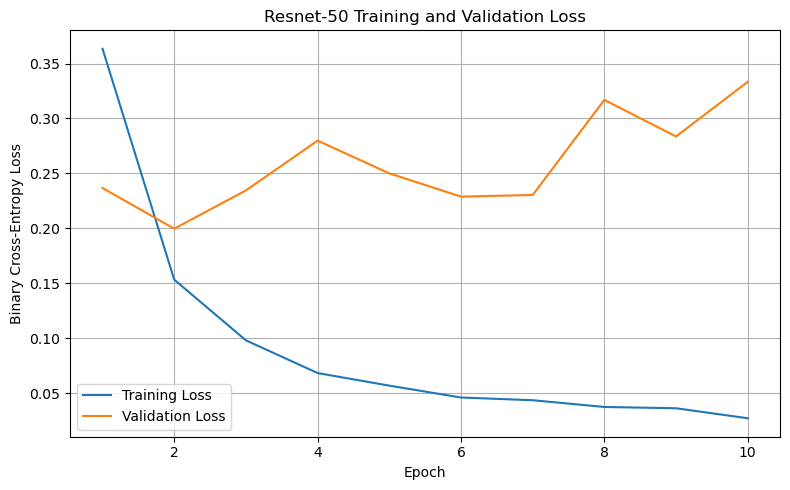

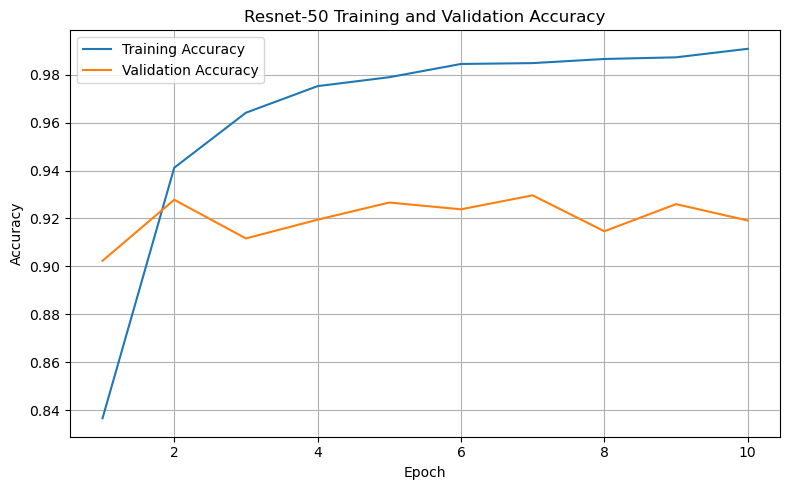

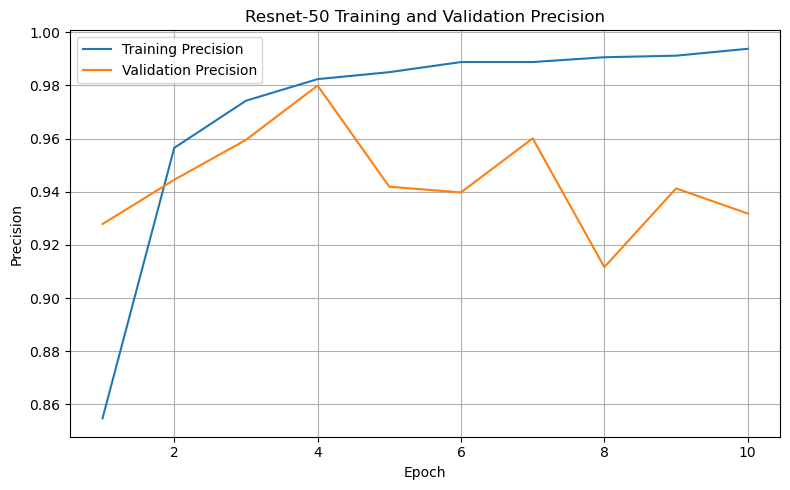

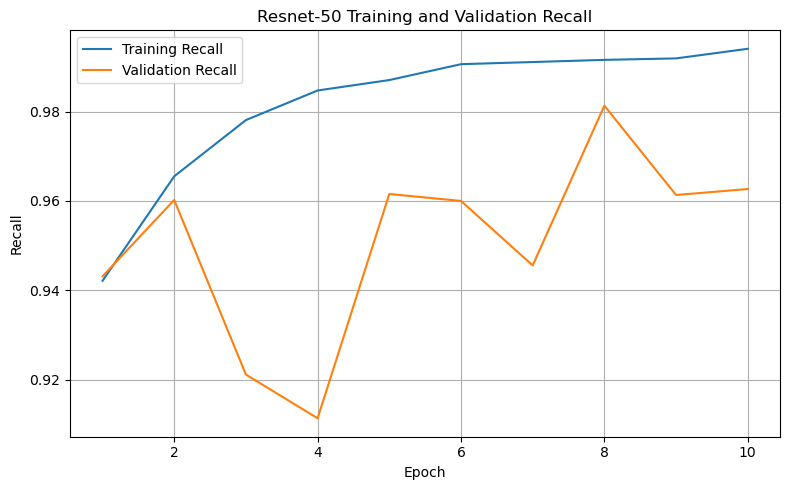

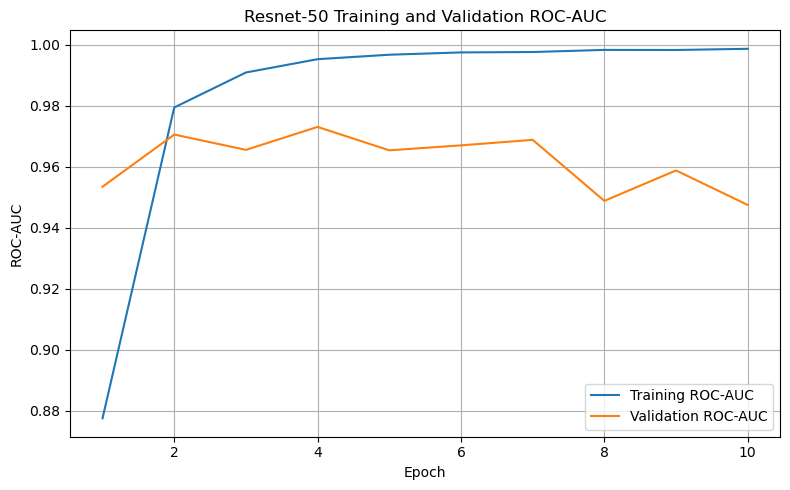

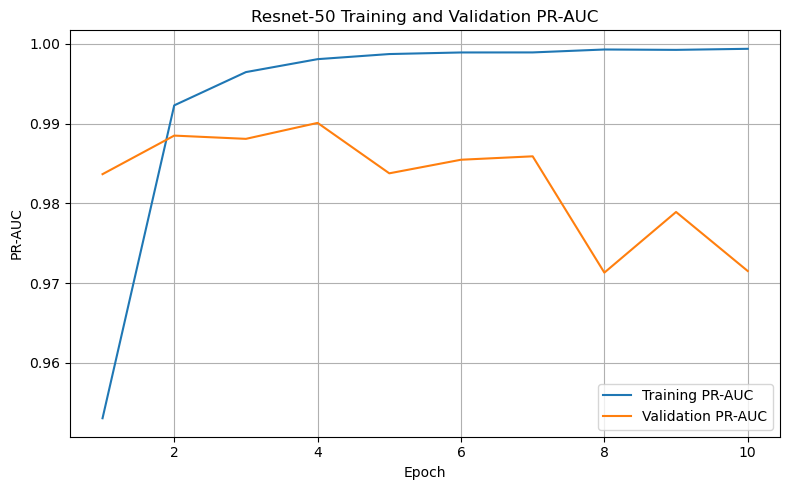

In [15]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Resnet-50 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Resnet-50 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Resnet-50 Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Resnet-50 Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Resnet-50 Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Resnet-50 Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

load the model

In [3]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"D:\thesis\results" r"\xception_wilddeepfake_10epochs.h5")

H5_PATH = (
    r"D:\thesis\dataset\WildDeepfake\leakage_free_subset"
    r"\wilddeepfake_sequence_disjoint_face_preprocessed.h5"
)

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

# Load only the test split
with h5py.File(H5_PATH, "r") as h5f:
    test_images = h5f["test_images"][:]
    test_labels = h5f["test_labels"][:]

print("Model loaded")
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

Model loaded
Test images: (18000, 160, 160, 3)
Test labels: (18000,)


In [11]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_images),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_images[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_images,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_images)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_28572\2159758100.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 25.21 seconds, 1.4004 ms/image

Starting resource run 2/5
Run 2: 24.31 seconds, 1.3505 ms/image

Starting resource run 3/5
Run 3: 23.10 seconds, 1.2836 ms/image

Starting resource run 4/5
Run 4: 22.07 seconds, 1.2259 ms/image

Starting resource run 5/5
Run 5: 22.59 seconds, 1.2552 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,25.207778,1.400432,714.065317,3.267914,5.375000,3004.210938,4345.698962,4364.125000,1341.488024,1359.914062,...,7000.53125,7000.53125,0.0,0.0,90.723684,100,57.923614,85.021,0.403176,1
1,24.309022,1.350501,740.465830,3.252287,4.928125,3041.582031,4381.056268,4398.691406,1339.474237,1357.109375,...,7000.53125,7000.53125,0.0,0.0,90.690909,100,62.153377,85.522,0.417679,2
2,23.104442,1.283580,779.070965,3.191235,5.328125,2501.804688,3840.717448,3859.808594,1338.912760,1358.003906,...,7000.53125,7000.53125,0.0,0.0,89.590476,93,64.516629,83.496,0.414115,3
3,22.066360,1.225909,815.721313,3.178420,5.193750,2501.894531,3840.313608,3860.375000,1338.419076,1358.480469,...,7000.53125,7000.53125,0.0,0.0,88.930348,100,72.258443,93.764,0.442090,4
4,22.593258,1.255181,796.697847,3.103826,4.881250,2503.039062,3840.964710,3861.148438,1337.925648,1358.109375,...,7000.53125,7000.53125,0.0,0.0,89.307317,100,67.267493,87.815,0.420807,5


In [16]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Resnet-50 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Resnet-50 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,23.456172,1.284074,21.861783,25.050561
1,latency_ms_per_image,1.303121,0.071337,1.214543,1.391698
2,throughput_images_per_s,769.204254,41.482785,717.696574,820.711935
3,average_cpu_percent,3.198737,0.065441,3.117481,3.279992
4,peak_cpu_percent,5.141250,0.226572,4.859923,5.422577
5,average_ram_mb,4049.750199,286.574222,3693.921305,4405.579093
6,peak_ram_mb,4068.829688,285.605826,3714.203216,4423.456159
7,average_incremental_ram_mb,1339.243949,1.379939,1337.530529,1340.957369
8,peak_incremental_ram_mb,1358.323437,1.021839,1357.054657,1359.592218
9,average_gpu_memory_mb,7000.531250,0.000000,7000.531250,7000.531250



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 1.303 ± 0.071 (95% CI: 1.215–1.392)
peak_ram_mb: 4068.830 ± 285.606 (95% CI: 3714.203–4423.456)
peak_gpu_memory_mb: 7000.531 ± 0.000 (95% CI: 7000.531–7000.531)
average_gpu_utilization_percent: 89.849 ± 0.818 (95% CI: 88.833–90.865)
average_gpu_power_w: 64.824 ± 5.387 (95% CI: 58.135–71.513)


In [19]:
#celeb on wilddeepfake
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of wild deepfake dataset on Celeb-DF(V2) (Resnet-50):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


373/373 [==============================] - 10s 24ms/step - loss: 1.0944 - accuracy: 0.6252 - precision: 0.9290 - recall: 0.6340 - roc_auc: 0.6248 - pr_auc: 0.9328

Test results of wild deepfake dataset on Celeb-DF(V2) (Resnet-50):
loss: 1.0944
accuracy: 0.6252
precision: 0.9290
recall: 0.6340
roc_auc: 0.6248
pr_auc: 0.9328


In [21]:
#dfc on wilddeepfake

test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of wild deepfake dataset on DFC (Resnet-50):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

188/188 [==============================] - 6s 25ms/step - loss: 2.5402 - accuracy: 0.4580 - precision: 0.4180 - recall: 0.2140 - roc_auc: 0.4337 - pr_auc: 0.4436

Test results of wild deepfake dataset on DFC (Resnet-50):
loss: 2.5402
accuracy: 0.4580
precision: 0.4180
recall: 0.2140
roc_auc: 0.4337
pr_auc: 0.4436


In [23]:
#ff++ on wilddeepfake

test_results = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of wild deepfake dataset on FF++ (Resnet-50):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

155/155 [==============================] - 4s 25ms/step - loss: 1.6256 - accuracy: 0.5717 - precision: 0.4788 - recall: 0.3172 - roc_auc: 0.5433 - pr_auc: 0.4636

Test results of wild deepfake dataset on FF++ (Resnet-50):
loss: 1.6256
accuracy: 0.5717
precision: 0.4788
recall: 0.3172
roc_auc: 0.5433
pr_auc: 0.4636


# Celeb

In [15]:
import os
import cv2
import numpy as np

SAVE_ROOT = r'D:\thesis\celeb_processed'

def load_split(split_name, class_name):
    """Reload saved frames, grouped by video."""
    base = os.path.join(SAVE_ROOT, split_name, class_name)
    nested, ids = [], []
    for vid_id in sorted(os.listdir(base)):
        vid_dir = os.path.join(base, vid_id)
        frames = [cv2.imread(os.path.join(vid_dir, f))
                  for f in sorted(os.listdir(vid_dir))]
        if frames:
            nested.append(frames)
            ids.append(vid_id)
    return nested, ids

# Reload ALL six splits
print("Loading frames...")
real_train_final,  real_train_ids  = load_split('train', 'real')
synth_train_final, synth_train_ids = load_split('train', 'fake')
real_val_final,    real_val_ids    = load_split('val',   'real')
synth_val_final,   synth_val_ids   = load_split('val',   'fake')
real_test_final,   real_test_ids   = load_split('test',  'real')
synth_test_final,  synth_test_ids  = load_split('test',  'fake')

print("✅ All frames reloaded")
print("Train -> real videos:", len(real_train_final), " fake videos:", len(synth_train_final))
print("Val   -> real videos:", len(real_val_final),   " fake videos:", len(synth_val_final))
print("Test  -> real videos:", len(real_test_final),  " fake videos:", len(synth_test_final))
print("Example frame shape:", np.shape(real_train_final[0][0]))  # expect (160,160,3)
import numpy as np


def combine_split(real_videos, fake_videos):
    """
    Flatten video-grouped frames into one image array and create labels.

    real_videos: list of videos, where each video is a list of frames
    fake_videos: list of videos, where each video is a list of frames

    Returns
    -------
    images : NumPy array with shape (N, 160, 160, 3)
    labels : NumPy array with shape (N,)
             0 = real, 1 = fake
    """

    # Flatten frames from all real videos
    real_frames = [
        frame
        for video_frames in real_videos
        for frame in video_frames
        if frame is not None
    ]

    # Flatten frames from all fake videos
    fake_frames = [
        frame
        for video_frames in fake_videos
        for frame in video_frames
        if frame is not None
    ]

    if len(real_frames) == 0:
        raise ValueError("No real frames were found.")

    if len(fake_frames) == 0:
        raise ValueError("No fake frames were found.")

    # Convert to NumPy arrays
    real_frames = np.stack(real_frames).astype(np.uint8)
    fake_frames = np.stack(fake_frames).astype(np.uint8)

    # Combine images
    images = np.concatenate(
        [real_frames, fake_frames],
        axis=0
    )

    # Create labels
    real_labels = np.zeros(
        len(real_frames),
        dtype=np.uint8
    )

    fake_labels = np.ones(
        len(fake_frames),
        dtype=np.uint8
    )

    labels = np.concatenate(
        [real_labels, fake_labels],
        axis=0
    )

    return images, labels
# Training set
train_celeb, train_labels = combine_split(
    real_train_final,
    synth_train_final
)

# Validation set
val_celeb, val_labels = combine_split(
    real_val_final,
    synth_val_final
)

# Testing set
test_celeb, test_labels = combine_split(
    real_test_final,
    synth_test_final
)
print("\nTRAIN")
print("Images:", train_celeb.shape)
print("Labels:", train_labels.shape)
print("Real:", np.sum(train_labels == 0))
print("Fake:", np.sum(train_labels == 1))

print("\nVALIDATION")
print("Images:", val_celeb.shape)
print("Labels:", val_labels.shape)
print("Real:", np.sum(val_labels == 0))
print("Fake:", np.sum(val_labels == 1))

print("\nTEST")
print("Images:", test_celeb.shape)
print("Labels:", test_labels.shape)
print("Real:", np.sum(test_labels == 0))
print("Fake:", np.sum(test_labels == 1))

print("\nData types")
print("Train images:", train_celeb.dtype)
print("Train labels:", train_labels.dtype)

Loading frames...
✅ All frames reloaded
Train -> real videos: 354  fake videos: 3383
Val   -> real videos: 59  fake videos: 563
Test  -> real videos: 177  fake videos: 1693
Example frame shape: (160, 160, 3)

TRAIN
Images: (11899, 160, 160, 3)
Labels: (11899,)
Real: 1142
Fake: 10757

VALIDATION
Images: (1969, 160, 160, 3)
Labels: (1969,)
Real: 182
Fake: 1787

TEST
Images: (5961, 160, 160, 3)
Labels: (5961,)
Real: 571
Fake: 5390

Data types
Train images: uint8
Train labels: uint8


In [4]:

# Train model
history = model.fit(
    train_celeb, train_labels,
    validation_data=(val_celeb, val_labels),
    epochs=10,
    batch_size=16,
    verbose=1
)

Epoch 1/10
744/744 [==============================] - 67s 79ms/step - loss: 0.3273 - accuracy: 0.9025 - precision: 0.9039 - recall: 0.9982 - roc_auc: 0.6044 - pr_auc: 0.9308 - val_loss: 0.2840 - val_accuracy: 0.9076 - val_precision: 0.9076 - val_recall: 1.0000 - val_roc_auc: 0.7815 - val_pr_auc: 0.9714
Epoch 2/10
744/744 [==============================] - 57s 77ms/step - loss: 0.2727 - accuracy: 0.9039 - precision: 0.9040 - recall: 0.9998 - roc_auc: 0.7792 - pr_auc: 0.9679 - val_loss: 0.2442 - val_accuracy: 0.9076 - val_precision: 0.9076 - val_recall: 1.0000 - val_roc_auc: 0.8739 - val_pr_auc: 0.9849
Epoch 3/10
744/744 [==============================] - 51s 68ms/step - loss: 0.2281 - accuracy: 0.9073 - precision: 0.9123 - recall: 0.9929 - roc_auc: 0.8697 - pr_auc: 0.9822 - val_loss: 0.2636 - val_accuracy: 0.9045 - val_precision: 0.9474 - val_recall: 0.9474 - val_roc_auc: 0.8843 - val_pr_auc: 0.9857
Epoch 4/10
744/744 [==============================] - 50s 67ms/step - loss: 0.1790 - acc

In [5]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [ ]:
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


373/373 [==============================] - 9s 23ms/step - loss: 0.2190 - accuracy: 0.9346 - precision: 0.9488 - recall: 0.9805 - roc_auc: 0.8927 - pr_auc: 0.9812

Test results:
loss: 0.2190
accuracy: 0.9346
precision: 0.9488
recall: 0.9805
roc_auc: 0.8927
pr_auc: 0.9812



In [ ]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_celeb,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Resnet-50 — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")
print(f"False-positive rate @ 0.5:  {false_positive_rate_at_05:.6f}")
print(f"False-negative rate @ 0.5:  {false_negative_rate_at_05:.6f}")

print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)


373/373 [==============================] - 7s 19ms/step

Mesonet — COMPLETE TEST-SET EVALUATION
Number of test samples:     5961
Decision threshold:         0.5000
Test loss:                  0.218997

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.934575 (93.46%)
Precision:                  0.948833 (94.88%)
Recall/Sensitivity:         0.980519 (98.05%)
F1-score:                   0.964416 (96.44%)
ROC-AUC:                    0.903466
PR-AUC:                     0.985892
Average Precision:          0.985797
EER:                        0.173889 (17.39%)
EER threshold:              0.950417

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.740698
Specificity:                0.500876
Matthews correlation:       0.572266
False-positive rate @ 0.5:  0.499124
False-negative rate @ 0.5:  0.019481

Confusion matrix
-------------------

In [7]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts


=== RESOURCE USAGE ===
CPU Usage: 13.9%
RAM Used: 438.2 MB
Time Usage: 11.0 s
GPU Memory Used: 1743.3 MB
Power Consumption: 93W


save the model

In [ ]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\Resnet-50_celeb_10epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)
# After training the model
model.save('Resnet-50_160_celeb.h5')  # Saves the entire model to a file

Model saved successfully:
D:\thesis\results\xception_celeb_10epochs.h5


Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


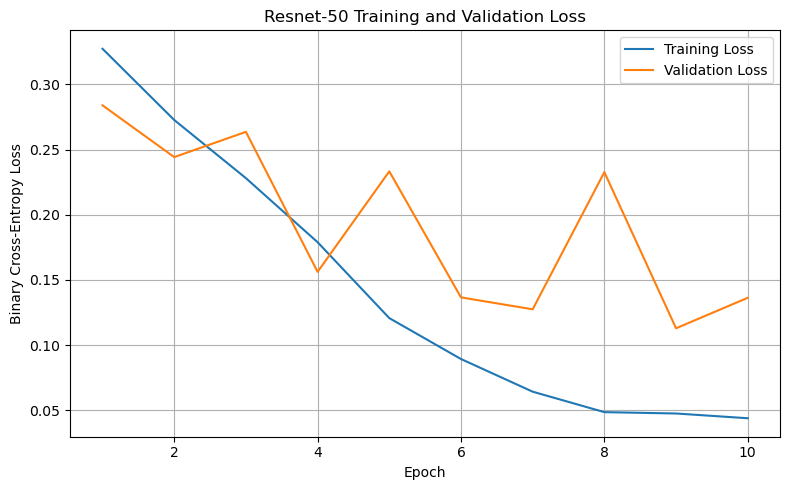

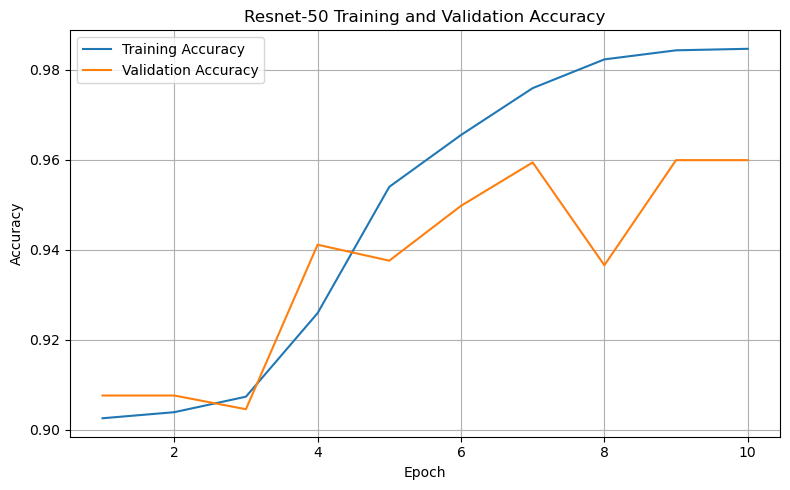

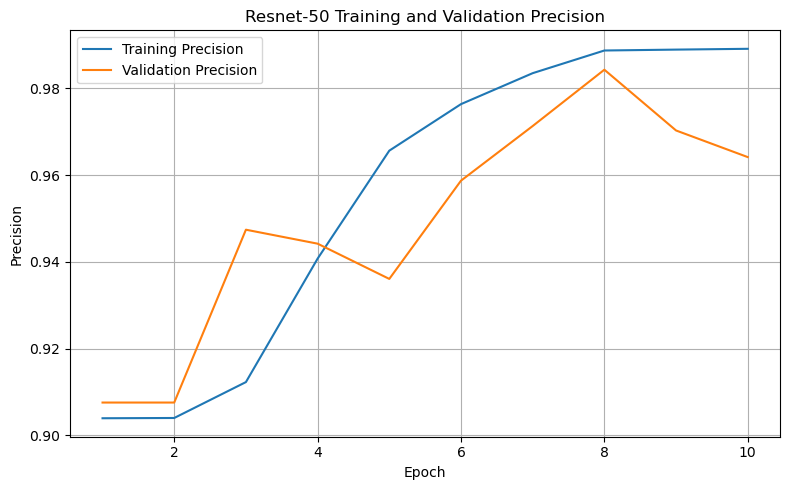

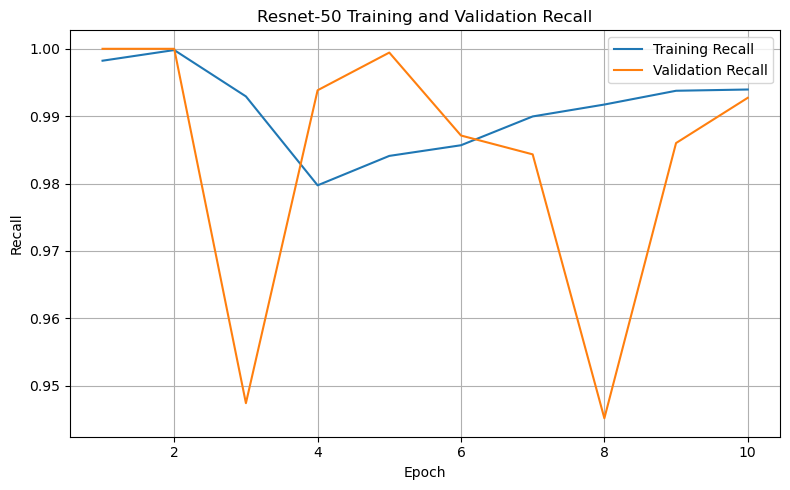

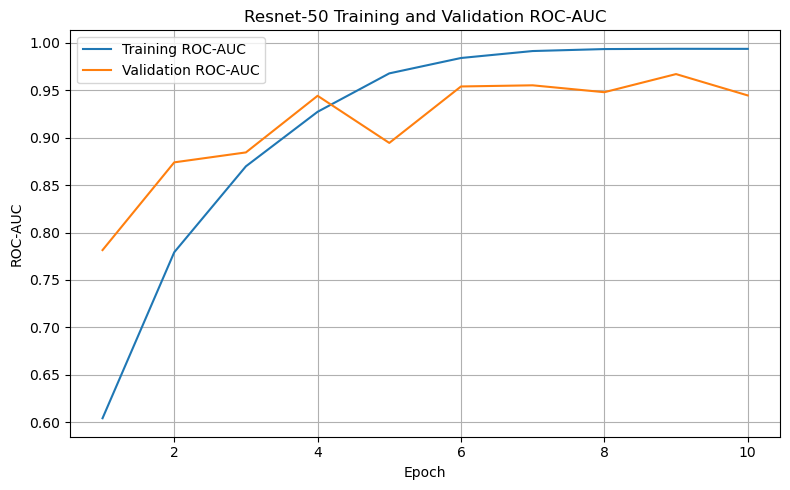

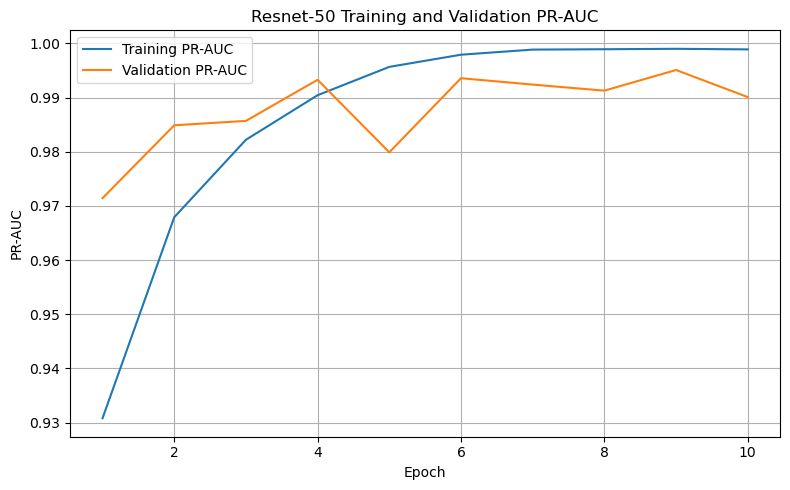

In [12]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Resnet-50 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Resnet-50 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Resnet-50 Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Resnet-50 Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Resnet-50 Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Resnet-50 Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

load the model

In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"D:\thesis\results" r"\Resnet-50_celeb_10epochs.h5")


model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)



In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"Resnet-50_160_celeb.h5")


In [9]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_celeb),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_celeb[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_celeb,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_celeb)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_15516\3984712684.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 8.53 seconds, 1.4306 ms/image

Starting resource run 2/5
Run 2: 7.70 seconds, 1.2919 ms/image

Starting resource run 3/5
Run 3: 7.68 seconds, 1.2877 ms/image

Starting resource run 4/5
Run 4: 7.63 seconds, 1.2807 ms/image

Starting resource run 5/5
Run 5: 7.58 seconds, 1.2722 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,8.528045,1.430640,698.987861,3.185759,5.825000,6886.074219,7361.328224,7382.636719,475.254005,496.562500,...,7003.675781,7003.675781,0.0,0.0,83.088608,92,55.563367,79.093,0.133805,1
1,7.701225,1.291935,774.032672,3.042914,5.328125,6914.371094,7375.648107,7392.609375,461.277014,478.238281,...,7003.675781,7003.675781,0.0,0.0,88.028169,94,61.221620,77.727,0.131175,2
2,7.676180,1.287734,776.558101,2.935739,4.675000,6918.242188,7377.933044,7394.125000,459.690856,475.882812,...,7003.675781,7003.675781,0.0,0.0,88.267606,91,61.253606,81.055,0.130753,3
3,7.634053,1.280667,780.843382,3.053345,6.300000,6919.468750,7378.140240,7395.578125,458.671490,476.109375,...,7003.675781,7003.675781,0.0,0.0,87.901408,91,62.196451,81.402,0.133107,4
4,7.583806,1.272237,786.016973,3.132098,4.478125,6920.042969,7379.467578,7396.632812,459.424609,476.589844,...,7003.675781,7003.675781,0.0,0.0,87.828571,91,65.053200,81.381,0.137223,5


In [10]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Resnet-50 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Resnet-50 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,7.824662,0.395719,7.333312,8.316012
1,latency_ms_per_image,1.312642,0.066385,1.230215,1.395070
2,throughput_images_per_s,763.287798,36.231372,718.300608,808.274988
3,average_cpu_percent,3.069971,0.095254,2.951698,3.188245
4,peak_cpu_percent,5.321250,0.764896,4.371507,6.270993
5,average_ram_mb,7374.503439,7.492125,7365.200737,7383.806140
6,peak_ram_mb,7392.316406,5.619683,7385.338648,7399.294165
7,average_incremental_ram_mb,462.863595,6.991176,454.182904,471.544286
8,peak_incremental_ram_mb,480.676562,8.928168,469.590778,491.762347
9,average_gpu_memory_mb,7003.675781,0.000000,7003.675781,7003.675781



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 1.313 ± 0.066 (95% CI: 1.230–1.395)
peak_ram_mb: 7392.316 ± 5.620 (95% CI: 7385.339–7399.294)
peak_gpu_memory_mb: 7003.676 ± 0.000 (95% CI: 7003.676–7003.676)
average_gpu_utilization_percent: 87.023 ± 2.206 (95% CI: 84.284–89.762)
average_gpu_power_w: 61.058 ± 3.447 (95% CI: 56.778–65.337)


#genralization

In [14]:
#wild deepfake on celeb
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of Celeb-DF(V2) on wild deepfake dataset (Resnet-50):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


1125/1125 [==============================] - 26s 23ms/step - loss: 1.3433 - accuracy: 0.5493 - precision: 0.7803 - recall: 0.5555 - roc_auc: 0.5468 - pr_auc: 0.7679

Test results of Celeb-DF(V2) on wild deepfake dataset (Resnet-50):
loss: 1.3433
accuracy: 0.5493
precision: 0.7803
recall: 0.5555
roc_auc: 0.5468
pr_auc: 0.7679


In [16]:
#DFC on celeb
test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of Celeb-DF(V2) on DFC dataset (Resnet-50):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



188/188 [==============================] - 6s 25ms/step - loss: 4.1723 - accuracy: 0.4843 - precision: 0.4919 - recall: 0.9547 - roc_auc: 0.4179 - pr_auc: 0.4550

Test results of Celeb-DF(V2) on DFC dataset (Resnet-50):
loss: 4.1723
accuracy: 0.4843
precision: 0.4919
recall: 0.9547
roc_auc: 0.4179
pr_auc: 0.4550


In [18]:
#FF++ on celeb
test_results = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)
print("\nTest results of Celeb-DF(V2) on FF++ dataset (Resnet-50):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



155/155 [==============================] - 3s 21ms/step - loss: 1.9852 - accuracy: 0.6073 - precision: 0.5155 - recall: 0.9534 - roc_auc: 0.8012 - pr_auc: 0.6733

Test results of Celeb-DF(V2) on FF++ dataset (Resnet-50):
loss: 1.9852
accuracy: 0.6073
precision: 0.5155
recall: 0.9534
roc_auc: 0.8012
pr_auc: 0.6733


# DFC

In [17]:
import h5py
import numpy as np
# Open the HDF5 file in read mode
with h5py.File('D://thesis//dataset//deepfake dataset//resized_images.h5', 'r') as h5f:
    # Access each dataset
    celeb = np.array(h5f['celeb'])
    ffhq = np.array(h5f['ffhq'])
    gdwct = np.array(h5f['gdwct'])
    attgan = np.array(h5f['attgan'])
    stargan = np.array(h5f['stargan'])
    stylegan2 = np.array(h5f['stylegan2'])
    stylegan = np.array(h5f['stylegan'])

# Now, 'celeb', 'ffhq', etc., are NumPy arrays containing your datasets
print(f"celeb shape: {celeb.shape}, dtype: {celeb.dtype}")
print(f"ffhq shape: {ffhq.shape}, dtype: {ffhq.dtype}")
print(f"ffhq shape: {gdwct.shape}, dtype: {gdwct.dtype}")
print(f"ffhq shape: {attgan.shape}, dtype: {attgan.dtype}")
print(f"ffhq shape: {stargan.shape}, dtype: {stargan.dtype}")
print(f"ffhq shape: {stylegan2.shape}, dtype: {stylegan2.dtype}")
print(f"ffhq shape: {stylegan.shape}, dtype: {stylegan.dtype}")
# Repeat for other datasets as needed
import cv2
# Function to resize images from (224, 224) to (160, 160)
def resize_images(image_array, target_size=(160, 160)):
    resized_images = np.array([cv2.resize(img, target_size) for img in image_array])
    return resized_images

celeb = resize_images(celeb, target_size=(160, 160))
ffhq = resize_images(ffhq, target_size=(160, 160))
gdwct = resize_images(gdwct, target_size=(160, 160))
attgan = resize_images(attgan, target_size=(160, 160))
stargan = resize_images(stargan, target_size=(160, 160))
stylegan = resize_images(stylegan, target_size=(160, 160))
stylegan2 = resize_images(stylegan2, target_size=(160, 160))
import random
# Randomly select 2500 distinct images
random_indices = random.sample(range(len(celeb)), 2500)  # Get 2500 random indices
celeb = celeb[random_indices]  # Select the random subse

import random
# Randomly select 2500 distinct images
random_indices = random.sample(range(len(ffhq)), 2500)  # Get 2500 random indices
ffhq = ffhq[random_indices]  # Select the random subse
print(f"celeb shape: {celeb.shape}, dtype: {celeb.dtype}")
print(f"ffhq shape: {ffhq.shape}, dtype: {ffhq.dtype}")
print(f"gdwct shape: {gdwct.shape}, dtype: {gdwct.dtype}")
print(f"attagan shape: {attgan.shape}, dtype: {attgan.dtype}")
print(f"stargan shape: {stargan.shape}, dtype: {stargan.dtype}")
print(f"stylegan2 shape: {stylegan2.shape}, dtype: {stylegan2.dtype}")
print(f"stylegan shape: {stylegan.shape}, dtype: {stylegan.dtype}")
import random
import numpy as np

def split_data(data, train_ratio=0.7):
    """
    Splits data into training and testing sets based on the specified ratio.

    Parameters:
        data (list or np.array): The dataset to split.
        train_ratio (float): The ratio of the data to include in the training set.

    Returns:
        tuple: Two datasets - train and test.
    """
    # Shuffle the data
    random.shuffle(data)

    # Calculate the split index
    split_index = int(len(data) * train_ratio)

    # Split the data
    train_data = data[:split_index]
    test_data = data[split_index:]

    return train_data, test_data

# Split `celeb` into 70% train and 30% test
celeb_train_hog, celeb_test_hog = split_data(celeb, train_ratio=0.7)

# Split `ffhq` into 70% train and 30% test
ffhq_train_hog, ffhq_test_hog = split_data(ffhq, train_ratio=0.7)

# Split `attgan` into 70% train and 30% test
attgan_train_hog, attgan_test_hog = split_data(attgan, train_ratio=0.7)

# Split `stargan` into 70% train and 30% test
stargan_train_hog, stargan_test_hog = split_data(stargan, train_ratio=0.7)

# Split `gdwct` into 70% train and 30% test
gdwct_train_hog, gdwct_test_hog = split_data(gdwct, train_ratio=0.7)

# Split `stylegan2` into 70% train and 30% test_hog
stylegan2_train_hog, stylegan2_test_hog = split_data(stylegan2, train_ratio=0.7)

# Split `stylegan` into 70% train and 30% test_hog
stylegan_train_hog, stylegan_test_hog = split_data(stylegan, train_ratio=0.7)

# Convert to NumPy arrays if needed
celeb_train_hog, celeb_test_hog = np.array(celeb_train_hog), np.array(celeb_test_hog)
ffhq_train_hog, ffhq_test_hog = np.array(ffhq_train_hog), np.array(ffhq_test_hog)
attgan_train_hog, attgan_test_hog = np.array(attgan_train_hog), np.array(attgan_test_hog)
stargan_train_hog, stargan_test_hog = np.array(stargan_train_hog), np.array(stargan_test_hog)
gdwct_train_hog, gdwct_test_hog = np.array(gdwct_train_hog), np.array(gdwct_test_hog)
stylegan2_train_hog, stylegan2_test_hog = np.array(stylegan2_train_hog), np.array(stylegan2_test_hog)
stylegan_train_hog, stylegan_test_hog = np.array(stylegan_train_hog), np.array(stylegan_test_hog)

# Print results for verification
print(f"celeb_train: {len(celeb_train_hog)} images, celeb_test: {len(celeb_test_hog)} images")
print(f"ffhq_train: {len(ffhq_train_hog)} images, ffhq_test: {len(ffhq_test_hog)} images")
print(f"attgan_train: {len(attgan_train_hog)} images, attgan_test: {len(attgan_test_hog)} images")
print(f"stargan_train: {len(stargan_train_hog)} images, stargan_test: {len(stargan_test_hog)} images")
print(f"gdwct_train: {len(gdwct_train_hog)} images, gdwct_test: {len(gdwct_test_hog)} images")
print(f"stylegan2_train: {len(stylegan2_train_hog)} images, stylegan2_test: {len(stylegan2_test_hog)} images")
print(f"stylegan_train: {len(stylegan_train_hog)} images, stylegan_test: {len(stylegan_test_hog)} images")

########################################################################################################################################
#######################################divide into 60,10 train and val
#########################################################################################################################################
def extract_validation(train_data):
    """
    Extract every 10th sample from the training data and store it in a validation set.

    Parameters:
        train_data (list or np.array): The training dataset.

    Returns:
        tuple: Updated training dataset and validation dataset.
    """
    # Select every 10th sample for the validation set
    validation_data = train_data[::10]

    # Remove the selected samples from the training dataset
    updated_train_data = [train_data[i] for i in range(len(train_data)) if i % 10 != 0]

    return np.array(updated_train_data), np.array(validation_data)


# Perform the operation for each dataset
celeb_train_hog, celeb_val_hog = extract_validation(celeb_train_hog)
ffhq_train_hog, ffhq_val_hog = extract_validation(ffhq_train_hog)
attgan_train_hog, attgan_val_hog = extract_validation(attgan_train_hog)
stargan_train_hog, stargan_val_hog = extract_validation(stargan_train_hog)
gdwct_train_hog, gdwct_val_hog = extract_validation(gdwct_train_hog)
stylegan2_train_hog, stylegan2_val_hog = extract_validation(stylegan2_train_hog)
stylegan_train_hog, stylegan_val_hog = extract_validation(stylegan_train_hog)

# Print results for verification
print(f"celeb_train: {len(celeb_train_hog)} images, celeb_val: {len(celeb_val_hog)} images")
print(f"ffhq_train: {len(ffhq_train_hog)} images, ffhq_val: {len(ffhq_val_hog)} images")
print(f"attgan_train: {len(attgan_train_hog)} images, attgan_val: {len(attgan_val_hog)} images")
print(f"stargan_train: {len(stargan_train_hog)} images, stargan_val: {len(stargan_val_hog)} images")
print(f"gdwct_train: {len(gdwct_train_hog)} images, gdwct_val: {len(gdwct_val_hog)} images")
print(f"stylegan2_train: {len(stylegan2_train_hog)} images, stylegan2_val: {len(stylegan2_val_hog)} images")
print(f"stylegan_train: {len(stylegan_train_hog)} images, stylegan_val: {len(stylegan_val_hog)} images")
############################################################################################################################################################
#################################################concatenate the labels 0,1 real and fake
#############################################################################################################################################################


celeb_train_labels = np.zeros(len(celeb_train_hog), dtype=int)
ffhq_train_labels = np.zeros(len(ffhq_train_hog), dtype=int)
atta_train_labels = np.ones(len(attgan_train_hog), dtype=int)
star_train_labels = np.ones(len(stargan_train_hog), dtype=int)
gdwct_train_labels = np.ones(len(gdwct_train_hog), dtype=int)
stylegan2_train_labels = np.ones(len(stylegan2_train_hog), dtype=int)
stylegan_train_labels = np.ones(len(stylegan_train_hog), dtype=int)

# Concatenate all training datasets into a single `train` variable
train_hog = np.concatenate([celeb_train_hog, ffhq_train_hog, attgan_train_hog, stargan_train_hog, gdwct_train_hog, stylegan2_train_hog, stylegan_train_hog], axis=0)
train_labels=np.concatenate([celeb_train_labels, ffhq_train_labels, atta_train_labels, star_train_labels, gdwct_train_labels, stylegan2_train_labels,
                              stylegan_train_labels], axis=0)




celeb_test_labels = np.zeros(len(celeb_test_hog), dtype=int)
ffhq_test_labels = np.zeros(len(ffhq_test_hog), dtype=int)
atta_test_labels = np.ones(len(attgan_test_hog), dtype=int)
star_test_labels = np.ones(len(stargan_test_hog), dtype=int)
gdwct_test_labels = np.ones(len(gdwct_test_hog), dtype=int)
stylegan2_test_labels = np.ones(len(stylegan2_test_hog), dtype=int)
stylegan_test_labels = np.ones(len(stylegan_test_hog), dtype=int)

# Concatenate all testing datasets into a single `test` variable
test_hog = np.concatenate([celeb_test_hog, ffhq_test_hog, attgan_test_hog, stargan_test_hog, gdwct_test_hog, stylegan2_test_hog, stylegan_test_hog], axis=0)
test_labels = np.concatenate([celeb_test_labels, ffhq_test_labels, atta_test_labels, star_test_labels, gdwct_test_labels, stylegan2_test_labels,
                        stylegan_test_labels], axis=0)




celeb_val_labels = np.zeros(len(celeb_val_hog), dtype=int)
ffhq_val_labels = np.zeros(len(ffhq_val_hog), dtype=int)
atta_val_labels = np.ones(len(attgan_val_hog), dtype=int)
star_val_labels = np.ones(len(stargan_val_hog), dtype=int)
gdwct_val_labels = np.ones(len(gdwct_val_hog), dtype=int)
stylegan2_val_labels = np.ones(len(stylegan2_val_hog), dtype=int)
stylegan_val_labels = np.ones(len(stylegan_val_hog), dtype=int)

# Concatenate all validation datasets into a single `val` variable
val_hog = np.concatenate([celeb_val_hog, ffhq_val_hog, attgan_val_hog, stargan_val_hog, gdwct_val_hog, stylegan2_val_hog, stylegan_val_hog], axis=0)
val_labels = np.concatenate([celeb_val_labels, ffhq_val_labels, atta_val_labels, star_val_labels, gdwct_val_labels, stylegan2_val_labels,
                       stylegan_val_labels], axis=0)

# Print the results for verification
print(f"Total train: {len(train_hog)} images")
print(f"Total test: {len(test_hog)} images")
print(f"Total val: {len(val_hog)} images")


# Print results for verification
print(f"Train Labels: {len(train_labels)} ")
print(f"Test Labels: {len(test_labels)} ")
print(f"Val Labels: {len(val_labels)} ")



celeb shape: (5000, 224, 224, 3), dtype: uint8
ffhq shape: (5000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
ffhq shape: (1000, 224, 224, 3), dtype: uint8
celeb shape: (2500, 160, 160, 3), dtype: uint8
ffhq shape: (2500, 160, 160, 3), dtype: uint8
gdwct shape: (1000, 160, 160, 3), dtype: uint8
attagan shape: (1000, 160, 160, 3), dtype: uint8
stargan shape: (1000, 160, 160, 3), dtype: uint8
stylegan2 shape: (1000, 160, 160, 3), dtype: uint8
stylegan shape: (1000, 160, 160, 3), dtype: uint8
celeb_train: 1750 images, celeb_test: 750 images
ffhq_train: 1750 images, ffhq_test: 750 images
attgan_train: 700 images, attgan_test: 300 images
stargan_train: 700 images, stargan_test: 300 images
gdwct_train: 700 images, gdwct_test: 300 images
stylegan2_train: 700 images, stylegan2_test: 300 images
stylegan_train: 700 images, stylegan

In [4]:

# Train model
history = model.fit(
    train_hog, train_labels,
    validation_data=(val_hog, val_labels),
    epochs=10,
    batch_size=16,
    verbose=1
)

Epoch 1/10
394/394 [==============================] - 37s 76ms/step - loss: 0.3546 - accuracy: 0.8398 - precision: 0.8437 - recall: 0.8343 - roc_auc: 0.9233 - pr_auc: 0.9248 - val_loss: 0.1268 - val_accuracy: 0.9557 - val_precision: 0.9443 - val_recall: 0.9686 - val_roc_auc: 0.9922 - val_pr_auc: 0.9930
Epoch 2/10
394/394 [==============================] - 28s 72ms/step - loss: 0.1122 - accuracy: 0.9590 - precision: 0.9556 - recall: 0.9629 - roc_auc: 0.9914 - pr_auc: 0.9913 - val_loss: 0.0830 - val_accuracy: 0.9786 - val_precision: 0.9745 - val_recall: 0.9829 - val_roc_auc: 0.9961 - val_pr_auc: 0.9970
Epoch 3/10
394/394 [==============================] - 26s 66ms/step - loss: 0.1007 - accuracy: 0.9668 - precision: 0.9664 - recall: 0.9673 - roc_auc: 0.9934 - pr_auc: 0.9937 - val_loss: 0.2716 - val_accuracy: 0.8943 - val_precision: 0.8286 - val_recall: 0.9943 - val_roc_auc: 0.9890 - val_pr_auc: 0.9805
Epoch 4/10
394/394 [==============================] - 26s 67ms/step - loss: 0.0329 - acc

In [5]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [ ]:
test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


188/188 [==============================] - 4s 22ms/step - loss: 0.1071 - accuracy: 0.9720 - precision: 0.9670 - recall: 0.9773 - roc_auc: 0.9914 - pr_auc: 0.9897

Test results:
loss: 0.1071
accuracy: 0.9720
precision: 0.9670
recall: 0.9773
roc_auc: 0.9914
pr_auc: 0.9897



In [ ]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_hog,
    test_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_hog,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Resnet-50 — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")
print(f"False-positive rate @ 0.5:  {false_positive_rate_at_05:.6f}")
print(f"False-negative rate @ 0.5:  {false_negative_rate_at_05:.6f}")

print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)


188/188 [==============================] - 4s 21ms/step

Resnet-50 — COMPLETE TEST-SET EVALUATION
Number of test samples:     3000
Decision threshold:         0.5000
Test loss:                  0.107118

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.972000 (97.20%)
Precision:                  0.967018 (96.70%)
Recall/Sensitivity:         0.977333 (97.73%)
F1-score:                   0.972149 (97.21%)
ROC-AUC:                    0.995095
PR-AUC:                     0.995712
Average Precision:          0.995691
EER:                        0.028333 (2.83%)
EER threshold:              0.612743

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.972000
Specificity:                0.966667
Matthews correlation:       0.944054
False-positive rate @ 0.5:  0.033333
False-negative rate @ 0.5:  0.022667

Confusion matrix
------------------

In [7]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts


=== RESOURCE USAGE ===
CPU Usage: 6.6%
RAM Used: 565.4 MB
Time Usage: 71.1 s
GPU Memory Used: 1023.4 MB
Power Consumption: 93W


save the model

In [8]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\Resnet-50_dfc_10epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)
# After training the model
model.save('Resnet-50_160_dfc.h5')  # Saves the entire model to a file

Model saved successfully:
D:\thesis\results\Resnet-50_dfc_10epochs.h5


Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


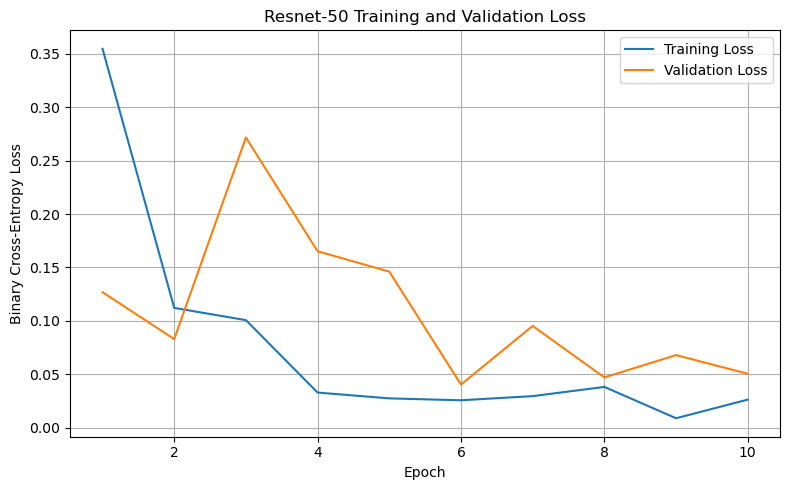

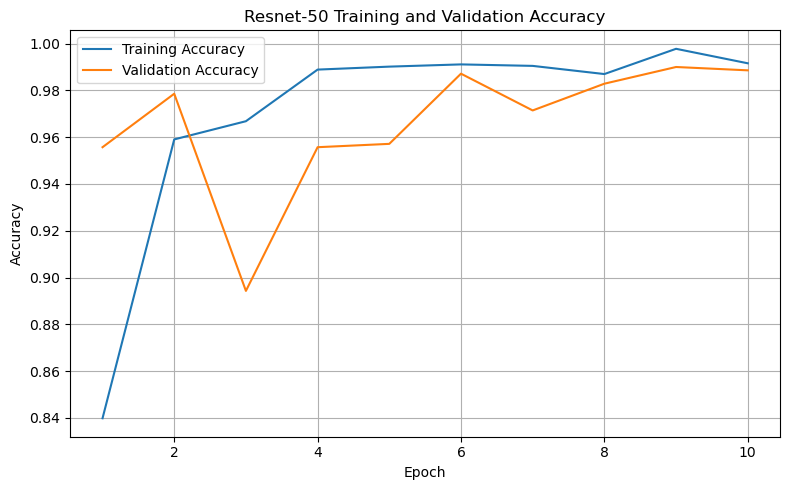

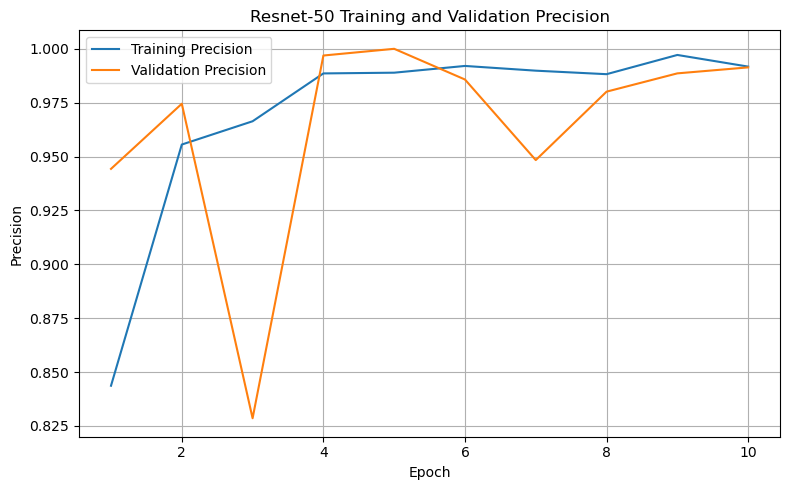

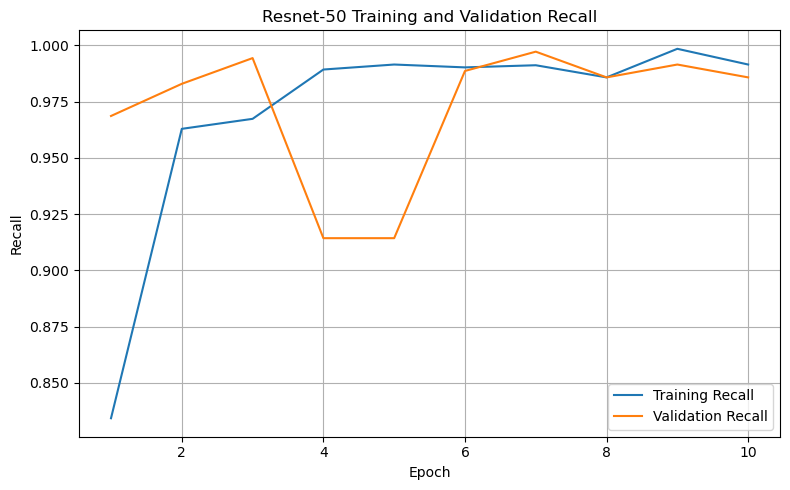

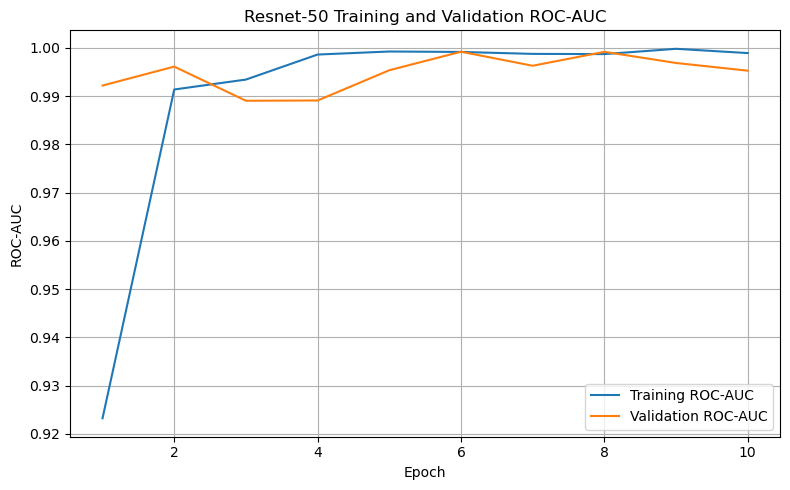

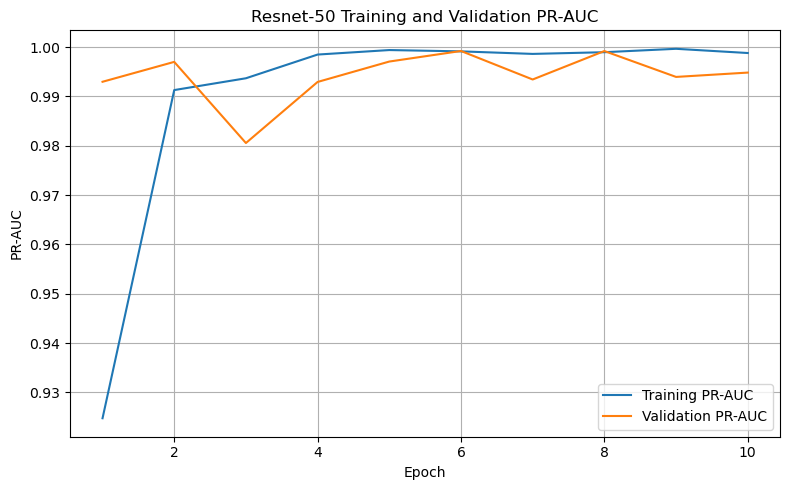

In [12]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Resnet-50 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Resnet-50 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Resnet-50 Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Resnet-50 Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Resnet-50 Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Resnet-50 Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#load the model

In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"D:\thesis\results" r"\Resnet-50_celeb_10epochs.h5")


model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)



In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"Resnet-50_160_dfc.h5")


In [ ]:
test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

In [9]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_hog),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_hog[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_hog,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_hog)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_36972\3709879675.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 4.54 seconds, 1.5123 ms/image

Starting resource run 2/5
Run 2: 4.08 seconds, 1.3583 ms/image

Starting resource run 3/5
Run 3: 4.06 seconds, 1.3520 ms/image

Starting resource run 4/5
Run 4: 3.83 seconds, 1.2778 ms/image

Starting resource run 5/5
Run 5: 3.93 seconds, 1.3102 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,4.536955,1.512318,661.236475,3.099855,5.328125,6162.234375,6418.582031,6441.292969,256.347656,279.058594,...,7005.425781,7005.425781,0.0,0.0,77.395349,92,50.678674,89.503,0.063838,1
1,4.075015,1.358338,736.193573,3.158894,4.928125,6183.960938,6424.207432,6442.710938,240.246494,258.750000,...,7005.425781,7005.425781,0.0,0.0,85.230769,92,52.125692,73.342,0.059648,2
2,4.055870,1.351957,739.668587,3.036924,4.296875,6184.554688,6424.695724,6442.695312,240.141036,258.140625,...,7005.425781,7005.425781,0.0,0.0,84.684211,92,53.075158,79.621,0.060866,3
3,3.833382,1.277794,782.598658,2.894679,4.568750,6185.082031,6424.080131,6443.265625,238.998100,258.183594,...,7005.425781,7005.425781,0.0,0.0,84.864865,93,58.352757,81.500,0.062916,4
4,3.930540,1.310180,763.253962,2.961102,9.156250,6185.125000,6424.865543,6443.449219,239.740543,258.324219,...,7005.425781,7005.425781,0.0,0.0,84.236842,93,56.397868,77.815,0.062694,5


In [10]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Resnet-50 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Resnet-50 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,4.086353,0.270357,3.750660,4.422045
1,latency_ms_per_image,1.362118,0.090119,1.250220,1.474015
2,throughput_images_per_s,736.590251,46.139874,679.300030,793.880472
3,average_cpu_percent,3.030291,0.105593,2.899180,3.161402
4,peak_cpu_percent,5.655625,1.994893,3.178639,8.132611
5,average_ram_mb,6423.286172,2.649966,6419.995805,6426.576539
6,peak_ram_mb,6442.682813,0.845527,6441.632952,6443.732673
7,average_incremental_ram_mb,243.094766,7.424786,233.875677,252.313855
8,peak_incremental_ram_mb,262.491406,9.264473,250.988044,273.994769
9,average_gpu_memory_mb,7005.425781,0.000000,7005.425781,7005.425781



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 1.362 ± 0.090 (95% CI: 1.250–1.474)
peak_ram_mb: 6442.683 ± 0.846 (95% CI: 6441.633–6443.733)
peak_gpu_memory_mb: 7005.426 ± 0.000 (95% CI: 7005.426–7005.426)
average_gpu_utilization_percent: 83.282 ± 3.310 (95% CI: 79.172–87.393)
average_gpu_power_w: 54.126 ± 3.163 (95% CI: 50.199–58.053)


#genralization

In [14]:
#wild deepfake on dfc
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of DFC on wild deepfake dataset (Resnet-50):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


1125/1125 [==============================] - 26s 23ms/step - loss: 3.1298 - accuracy: 0.3597 - precision: 0.8104 - recall: 0.1909 - roc_auc: 0.5766 - pr_auc: 0.7879

Test results of DFC on wild deepfake dataset (Resnet-50):
loss: 3.1298
accuracy: 0.3597
precision: 0.8104
recall: 0.1909
roc_auc: 0.5766
pr_auc: 0.7879


In [16]:
#celeb on celeb
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of DFC on Celeb-DF(V2) dataset (Resnet-50):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



373/373 [==============================] - 9s 21ms/step - loss: 1.6971 - accuracy: 0.6524 - precision: 0.9113 - recall: 0.6820 - roc_auc: 0.5339 - pr_auc: 0.9120

Test results of DFC on Celeb-DF(V2) dataset (Resnet-50):
loss: 1.6971
accuracy: 0.6524
precision: 0.9113
recall: 0.6820
roc_auc: 0.5339
pr_auc: 0.9120


In [18]:
#FF++ on hog
test_results = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)
print("\nTest results of dfc on FF++ dataset (Resnet-50):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")



155/155 [==============================] - 4s 23ms/step - loss: 3.5536 - accuracy: 0.4792 - precision: 0.4241 - recall: 0.6993 - roc_auc: 0.5144 - pr_auc: 0.4254

Test results of dfc on FF++ dataset (Resnet-50):
loss: 3.5536
accuracy: 0.4792
precision: 0.4241
recall: 0.6993
roc_auc: 0.5144
pr_auc: 0.4254


# FF++

LOAD THE DATASET

In [3]:
import os, cv2, numpy as np

FINAL_ROOT = r'D:\thesis\ff_final'

def load_split(split, cls):
    base = os.path.join(FINAL_ROOT, split, cls)
    nested, ids = [], []
    for vid_id in sorted(os.listdir(base)):
        d = os.path.join(base, vid_id)
        frames = [cv2.imread(os.path.join(d, f)) for f in sorted(os.listdir(d))]
        if frames:
            nested.append(frames); ids.append(vid_id)
    return nested, ids

# Main splits
ff_real_train_f, ff_real_train_ids = load_split('train', 'real')
ff_fake_train_f, ff_fake_train_ids = load_split('train', 'fake')
ff_real_val_f,   ff_real_val_ids   = load_split('val',   'real')
ff_fake_val_f,   ff_fake_val_ids   = load_split('val',   'fake')
ff_real_test_f,  ff_real_test_ids  = load_split('test',  'real')
ff_fake_test_f,  ff_fake_test_ids  = load_split('test',  'fake')

print("Reloaded main splits. Example shape:", np.shape(ff_real_train_f[0][0]))  # (160,160,3)
print("Real train videos:", len(ff_real_train_f), "| Fake train videos:", len(ff_fake_train_f))
import numpy as np


def combine_split(real_videos, fake_videos):
    """
    Combine all frames from the real and fake video groups.

    Labels:
        0 = Real
        1 = Fake
    """

    real_frames = [
        frame
        for video in real_videos
        for frame in video
        if frame is not None
    ]

    fake_frames = [
        frame
        for video in fake_videos
        for frame in video
        if frame is not None
    ]

    if not real_frames:
        raise ValueError("No real frames found.")

    if not fake_frames:
        raise ValueError("No fake frames found.")

    real_frames = np.stack(real_frames).astype(np.uint8)
    fake_frames = np.stack(fake_frames).astype(np.uint8)

    images = np.concatenate(
        [real_frames, fake_frames],
        axis=0
    )

    real_labels = np.zeros(
        len(real_frames),
        dtype=np.uint8
    )

    fake_labels = np.ones(
        len(fake_frames),
        dtype=np.uint8
    )

    labels = np.concatenate(
        [real_labels, fake_labels],
        axis=0
    )

    return images, labels
# Training data
train_ff, train_ff_labels = combine_split(
    ff_real_train_f,
    ff_fake_train_f
)

# Validation data
val_ff, val_ff_labels = combine_split(
    ff_real_val_f,
    ff_fake_val_f
)

# Testing data
test_ff, test_ff_labels = combine_split(
    ff_real_test_f,
    ff_fake_test_f
)
print("\nTRAIN")
print("Images:", train_ff.shape)
print("Labels:", train_ff_labels.shape)
print("Real:", np.sum(train_ff_labels == 0))
print("Fake:", np.sum(train_ff_labels == 1))

print("\nVALIDATION")
print("Images:", val_ff.shape)
print("Labels:", val_ff_labels.shape)
print("Real:", np.sum(val_ff_labels == 0))
print("Fake:", np.sum(val_ff_labels == 1))

print("\nTEST")
print("Images:", test_ff.shape)
print("Labels:", test_ff_labels.shape)
print("Real:", np.sum(test_ff_labels == 0))
print("Fake:", np.sum(test_ff_labels == 1))

print("\nData types")
print("Train images:", train_ff.dtype)
print("Train labels:", train_ff_labels.dtype)

Reloaded main splits. Example shape: (160, 160, 3)
Real train videos: 517 | Fake train videos: 320

TRAIN
Images: (4595, 160, 160, 3)
Labels: (4595,)
Real: 2948
Fake: 1647

VALIDATION
Images: (948, 160, 160, 3)
Labels: (948,)
Real: 499
Fake: 449

TEST
Images: (2475, 160, 160, 3)
Labels: (2475,)
Real: 1444
Fake: 1031

Data types
Train images: uint8
Train labels: uint8


In [4]:

# Train model
history = model.fit(
    train_ff, train_ff_labels,
    validation_data=(val_ff, val_ff_labels),
    epochs=10,
    batch_size=16,
    verbose=1
)

Epoch 1/10
288/288 [==============================] - 30s 81ms/step - loss: 0.3973 - accuracy: 0.8261 - precision: 0.8145 - recall: 0.6667 - roc_auc: 0.8776 - pr_auc: 0.8465 - val_loss: 0.3578 - val_accuracy: 0.8281 - val_precision: 0.9735 - val_recall: 0.6548 - val_roc_auc: 0.9512 - val_pr_auc: 0.9529
Epoch 2/10
288/288 [==============================] - 23s 79ms/step - loss: 0.2342 - accuracy: 0.9077 - precision: 0.9209 - recall: 0.8124 - roc_auc: 0.9575 - pr_auc: 0.9443 - val_loss: 0.2689 - val_accuracy: 0.8819 - val_precision: 0.8562 - val_recall: 0.9020 - val_roc_auc: 0.9629 - val_pr_auc: 0.9598
Epoch 3/10
288/288 [==============================] - 23s 79ms/step - loss: 0.1933 - accuracy: 0.9308 - precision: 0.9380 - recall: 0.8640 - roc_auc: 0.9712 - pr_auc: 0.9623 - val_loss: 0.2080 - val_accuracy: 0.9114 - val_precision: 0.8858 - val_recall: 0.9332 - val_roc_auc: 0.9777 - val_pr_auc: 0.9741
Epoch 4/10
288/288 [==============================] - 23s 79ms/step - loss: 0.1615 - acc

In [5]:
print("=== DATA LOADING ===")
start = monitor.get_stats()

=== DATA LOADING ===


In [ ]:
test_results = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


155/155 [==============================] - 3s 21ms/step - loss: 0.4574 - accuracy: 0.8715 - precision: 0.7757 - recall: 0.9728 - roc_auc: 0.9782 - pr_auc: 0.9728

Test results:
loss: 0.4574
accuracy: 0.8715
precision: 0.7757
recall: 0.9728
roc_auc: 0.9782
pr_auc: 0.9728



In [ ]:
# ============================================================
# COMPLETE TEST EVALUATION
# Labels: 0 = Real, 1 = Fake
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

BATCH_SIZE = 16
DECISION_THRESHOLD = 0.50


# ------------------------------------------------------------
# 1. Test loss
# ------------------------------------------------------------

evaluation = model.evaluate(
    test_ff,
    test_ff_labels,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True
)

test_loss = evaluation["loss"]


# ------------------------------------------------------------
# 2. Prediction probabilities and binary predictions
# ------------------------------------------------------------

test_probabilities = model.predict(
    test_hog,
    batch_size=BATCH_SIZE,
    verbose=1
).reshape(-1)

y_true = np.asarray(test_labels).reshape(-1).astype(np.uint8)

y_pred = (
    test_probabilities >= DECISION_THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()


# ------------------------------------------------------------
# 4. Threshold-dependent metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

false_positive_rate_at_05 = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

false_negative_rate_at_05 = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# 5. ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)

fpr, tpr, roc_thresholds = roc_curve(
    y_true,
    test_probabilities,
    pos_label=1
)


# ------------------------------------------------------------
# 6. PR-AUC and Average Precision
# ------------------------------------------------------------

pr_precision, pr_recall, _ = precision_recall_curve(
    y_true,
    test_probabilities,
    pos_label=1
)

# Reverse because recall is normally returned in descending order
pr_auc = auc(
    pr_recall[::-1],
    pr_precision[::-1]
)

average_precision = average_precision_score(
    y_true,
    test_probabilities
)


# ------------------------------------------------------------
# 7. Equal Error Rate
# ------------------------------------------------------------

fnr_curve = 1.0 - tpr

# Remove non-finite thresholds such as infinity
valid_indices = np.where(
    np.isfinite(roc_thresholds)
)[0]

eer_index = valid_indices[
    np.argmin(
        np.abs(
            fpr[valid_indices]
            - fnr_curve[valid_indices]
        )
    )
]

eer = (
    fpr[eer_index]
    + fnr_curve[eer_index]
) / 2.0

eer_threshold = roc_thresholds[eer_index]


# ------------------------------------------------------------
# 8. Display all results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Resnet-50 — COMPLETE TEST-SET EVALUATION")
print("=" * 70)

print(f"Number of test samples:     {len(y_true)}")
print(f"Decision threshold:         {DECISION_THRESHOLD:.4f}")
print(f"Test loss:                  {test_loss:.6f}")

print("\nMain evaluation metrics")
print("-" * 70)
print(f"Accuracy:                   {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision:                  {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall/Sensitivity:         {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score:                   {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC:                    {roc_auc:.6f}")
print(f"PR-AUC:                     {pr_auc:.6f}")
print(f"Average Precision:          {average_precision:.6f}")
print(f"EER:                        {eer:.6f} ({eer*100:.2f}%)")
print(f"EER threshold:              {eer_threshold:.6f}")

print("\nAdditional evaluation metrics")
print("-" * 70)
print(f"Balanced accuracy:          {balanced_accuracy:.6f}")
print(f"Specificity:                {specificity:.6f}")
print(f"Matthews correlation:       {mcc:.6f}")
print(f"False-positive rate @ 0.5:  {false_positive_rate_at_05:.6f}")
print(f"False-negative rate @ 0.5:  {false_negative_rate_at_05:.6f}")

print("\nConfusion matrix")
print("-" * 70)
print("Rows = actual classes; columns = predicted classes")
print("Class order: [Real, Fake]")
print(cm)

print("\nConfusion-matrix values")
print("-" * 70)
print(f"True Negative  — Real predicted as Real: {tn}")
print(f"False Positive — Real predicted as Fake: {fp}")
print(f"False Negative — Fake predicted as Real: {fn}")
print(f"True Positive  — Fake predicted as Fake: {tp}")

print("\nClassification report")
print("-" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Real", "Fake"],
        digits=6,
        zero_division=0
    )
)


155/155 [==============================] - 3s 19ms/step

Resnet-50 — COMPLETE TEST-SET EVALUATION
Number of test samples:     2475
Decision threshold:         0.5000
Test loss:                  0.457423

Main evaluation metrics
----------------------------------------------------------------------
Accuracy:                   0.871515 (87.15%)
Precision:                  0.775715 (77.57%)
Recall/Sensitivity:         0.972842 (97.28%)
F1-score:                   0.863167 (86.32%)
ROC-AUC:                    0.978221
PR-AUC:                     0.972806
Average Precision:          0.972341
EER:                        0.081250 (8.13%)
EER threshold:              0.953608

Additional evaluation metrics
----------------------------------------------------------------------
Balanced accuracy:          0.886005
Specificity:                0.799169
Matthews correlation:       0.761953
False-positive rate @ 0.5:  0.200831
False-negative rate @ 0.5:  0.027158

Confusion matrix
------------------

In [7]:
# Your data loading operations here
time.sleep(2)  # Simulate loading time

end = monitor.get_stats()
duration = end['timestamp'] - start['timestamp']

print("\n=== RESOURCE USAGE ===")
print(f"CPU Usage: {end['cpu_%']:.1f}%")
print(f"RAM Used: {end['ram_mb'] - start['ram_mb']:.1f} MB")
print(f"Time Usage: {duration:.1f} s")
print(f"GPU Memory Used: {end['gpu_mem_mb']:.1f} MB")
print(f"Power Consumption: {int(end['power_w'])}W")  # Rounded to whole watts


=== RESOURCE USAGE ===
CPU Usage: 9.7%
RAM Used: 85.5 MB
Time Usage: 5.5 s
GPU Memory Used: 907.1 MB
Power Consumption: 93W


#save the model

In [8]:
MODEL_PATH = (
    r"D:\thesis\results"
    r"\Resnet-50_ff_10epochs.h5"
)

model.save(
    MODEL_PATH,
    include_optimizer=True
)

print("Model saved successfully:")
print(MODEL_PATH)
# After training the model
model.save('Resnet-50_160_ff.h5')  # Saves the entire model to a file

Model saved successfully:
D:\thesis\results\Resnet-50_ff_10epochs.h5


Available history metrics:
['loss', 'accuracy', 'precision', 'recall', 'roc_auc', 'pr_auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_roc_auc', 'val_pr_auc']


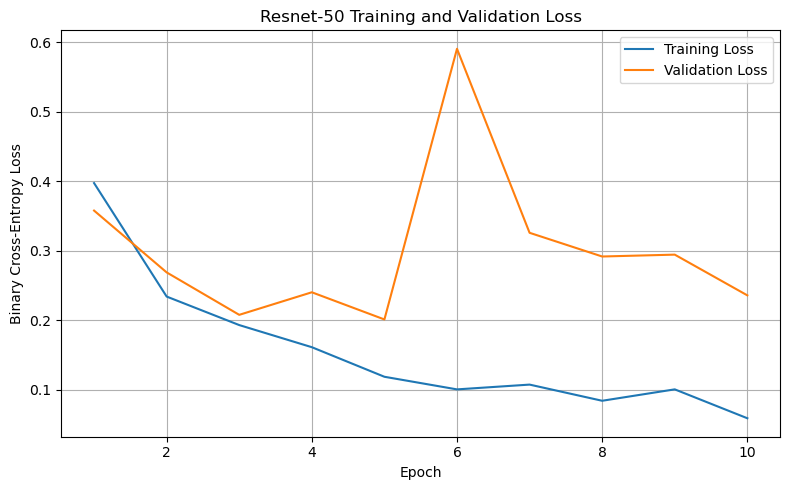

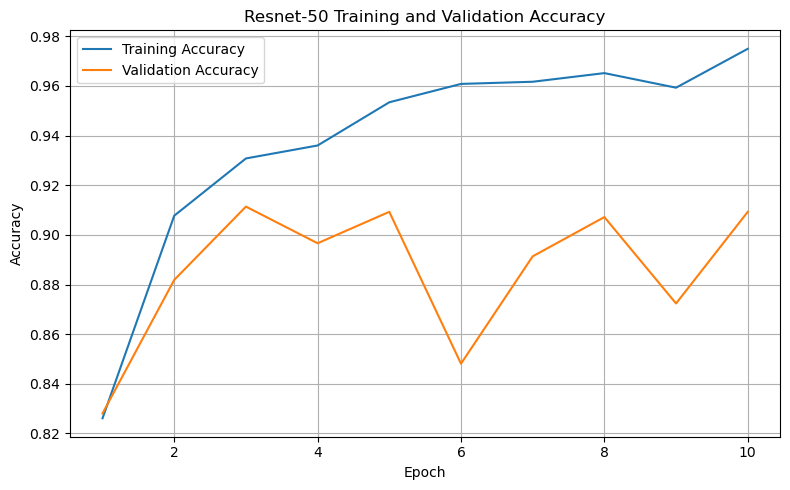

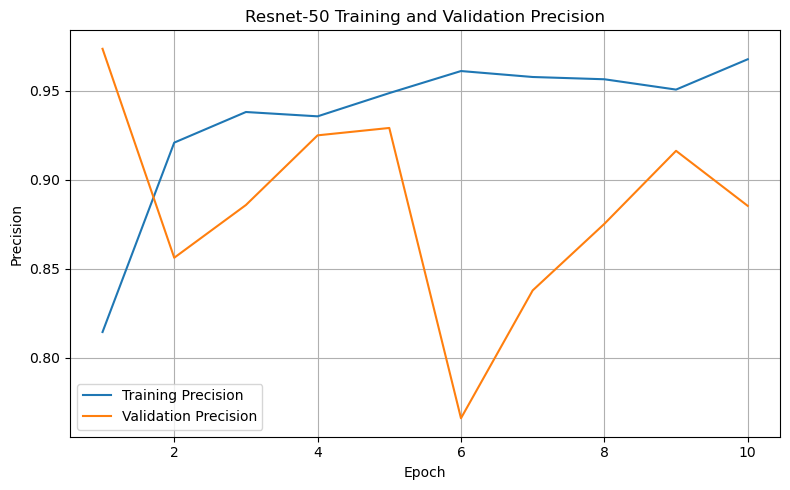

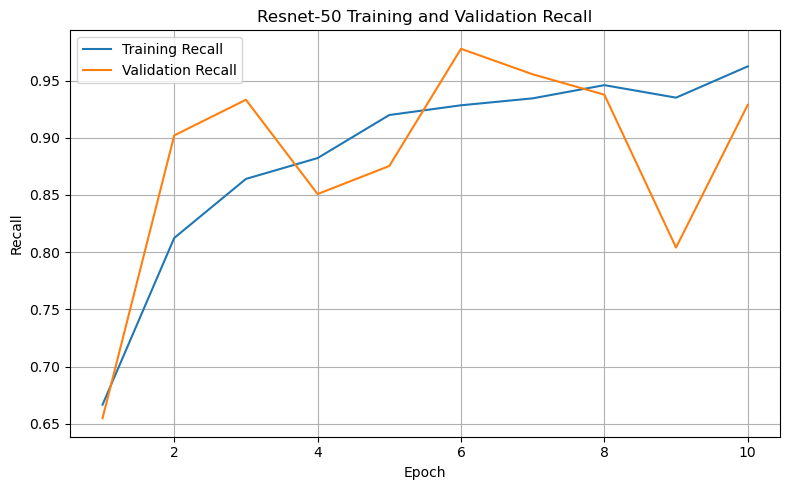

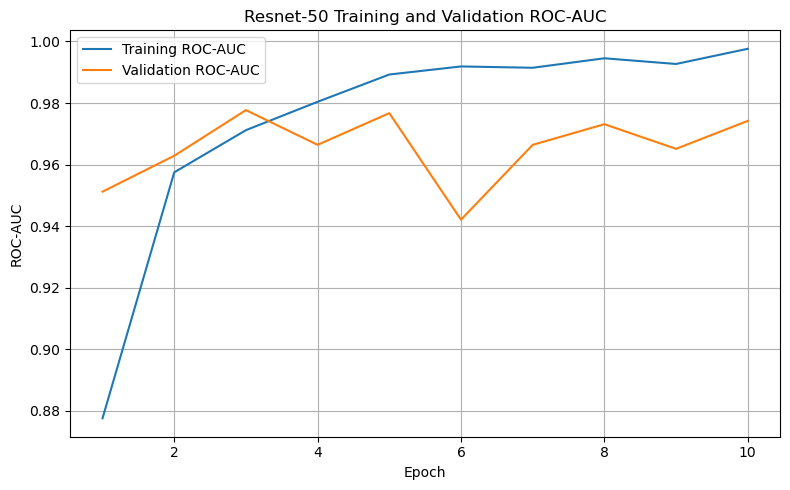

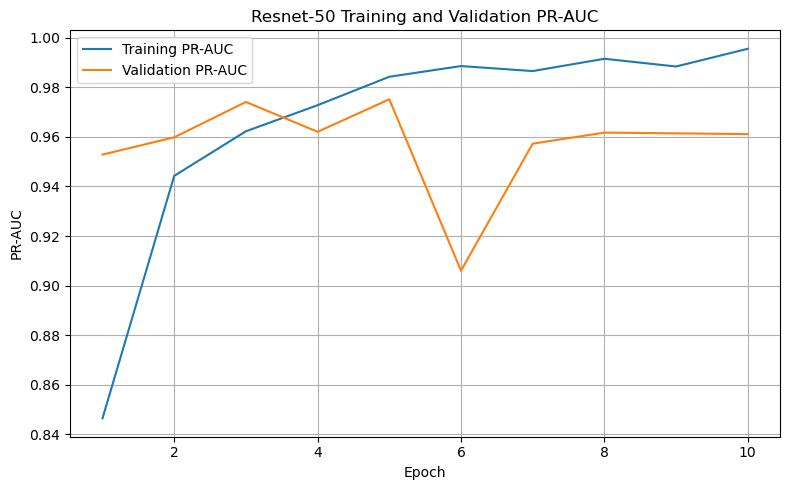

In [12]:
# ============================================================TRAINING AND VALIDATION CURVES
# TRAINING AND VALIDATION CURVES
# Run after model.fit(...)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Available values recorded during training
history_data = history.history

print("Available history metrics:")
print(list(history_data.keys()))

epochs = np.arange(1, len(history_data["loss"]) + 1)


# ------------------------------------------------------------
# 1. Training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Resnet-50 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Resnet-50 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Training and validation precision
# ------------------------------------------------------------

if (
    "precision" in history_data
    and "val_precision" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["precision"],
        label="Training Precision"
    )

    plt.plot(
        epochs,
        history_data["val_precision"],
        label="Validation Precision"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Resnet-50 Training and Validation Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Training and validation recall
# ------------------------------------------------------------

if (
    "recall" in history_data
    and "val_recall" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["recall"],
        label="Training Recall"
    )

    plt.plot(
        epochs,
        history_data["val_recall"],
        label="Validation Recall"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Resnet-50 Training and Validation Recall")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5. Training and validation ROC-AUC
# ------------------------------------------------------------

if (
    "roc_auc" in history_data
    and "val_roc_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Resnet-50 Training and Validation ROC-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Training and validation PR-AUC
# ------------------------------------------------------------

if (
    "pr_auc" in history_data
    and "val_pr_auc" in history_data
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history_data["pr_auc"],
        label="Training PR-AUC"
    )

    plt.plot(
        epochs,
        history_data["val_pr_auc"],
        label="Validation PR-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("PR-AUC")
    plt.title("Resnet-50 Training and Validation PR-AUC")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#load the model

In [ ]:
import h5py
import tensorflow as tf

MODEL_PATH = ( r"D:\thesis\results" r"\Resnet-50_ff_10epochs.h5")


model = tf.keras.models.load_model(MODEL_PATH,compile=False)

In [9]:
# ============================================================
# REPEATED INFERENCE RESOURCE PROFILING
# ============================================================

import os
import gc
import time
import threading
import numpy as np
import pandas as pd
import psutil

from scipy.stats import t

from pynvml import (
    nvmlInit,
    nvmlShutdown,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetMemoryInfo,
    nvmlDeviceGetUtilizationRates,
    nvmlDeviceGetPowerUsage,
    NVMLError
)


BATCH_SIZE = 16
NUMBER_OF_RUNS = 5
SAMPLING_INTERVAL = 0.1     # Sample every 100 milliseconds
COOLDOWN_SECONDS = 5
GPU_INDEX = 0


class ResourceMonitor:
    """
    Continuously measures resource consumption during one inference run.

    RAM:
        Current Python process resident memory (RSS).

    GPU memory:
        Total device memory currently used, with the pre-inference
        baseline subtracted for incremental measurements.

    CPU:
        Current Python-process CPU utilization normalized by the
        number of logical CPU cores.

    Power:
        NVIDIA GPU board power reported by NVML.
    """

    def __init__(
        self,
        interval=0.1,
        gpu_index=0
    ):
        self.interval = interval
        self.process = psutil.Process(os.getpid())

        self.logical_cpu_count = (
            psutil.cpu_count(logical=True) or 1
        )

        self.stop_event = threading.Event()
        self.samples = []
        self.thread = None

        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(
            gpu_index
        )

    def _read_gpu_power(self):
        try:
            return (
                nvmlDeviceGetPowerUsage(
                    self.gpu_handle
                ) / 1000.0
            )
        except NVMLError:
            return np.nan

    def _collect_sample(self):
        timestamp = time.perf_counter()

        # Process RAM: resident set size
        ram_mb = (
            self.process.memory_info().rss
            / (1024 ** 2)
        )

        # Process CPU percentage can exceed 100% on multicore systems.
        # Normalize it to an approximate 0–100% scale.
        process_cpu_raw = self.process.cpu_percent(
            interval=None
        )

        process_cpu_normalized = (
            process_cpu_raw
            / self.logical_cpu_count
        )

        gpu_memory = nvmlDeviceGetMemoryInfo(
            self.gpu_handle
        )

        gpu_memory_used_mb = (
            gpu_memory.used
            / (1024 ** 2)
        )

        gpu_utilization = nvmlDeviceGetUtilizationRates(
            self.gpu_handle
        ).gpu

        gpu_power_w = self._read_gpu_power()

        self.samples.append({
            "timestamp": timestamp,
            "ram_mb": ram_mb,
            "cpu_percent": process_cpu_normalized,
            "gpu_memory_mb": gpu_memory_used_mb,
            "gpu_utilization_percent": gpu_utilization,
            "gpu_power_w": gpu_power_w
        })

    def _sampling_loop(self):
        while not self.stop_event.is_set():
            try:
                self._collect_sample()
            except Exception as error:
                print("Monitoring warning:", error)

            self.stop_event.wait(self.interval)

    def start(self):
        # Initialize CPU counters
        self.process.cpu_percent(interval=None)

        # First sample is the pre-inference baseline
        self._collect_sample()

        self.thread = threading.Thread(
            target=self._sampling_loop,
            daemon=True
        )

        self.thread.start()

    def stop(
        self,
        elapsed_seconds,
        number_of_images
    ):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join()

        # Capture one final sample
        try:
            self._collect_sample()
        except Exception:
            pass

        nvmlShutdown()

        data = pd.DataFrame(self.samples)

        baseline_ram = data["ram_mb"].iloc[0]
        baseline_gpu_memory = data[
            "gpu_memory_mb"
        ].iloc[0]

        peak_ram = data["ram_mb"].max()
        average_ram = data["ram_mb"].mean()

        peak_gpu_memory = data[
            "gpu_memory_mb"
        ].max()

        average_gpu_memory = data[
            "gpu_memory_mb"
        ].mean()

        peak_incremental_ram = max(
            0.0,
            peak_ram - baseline_ram
        )

        average_incremental_ram = max(
            0.0,
            average_ram - baseline_ram
        )

        peak_incremental_gpu_memory = max(
            0.0,
            peak_gpu_memory - baseline_gpu_memory
        )

        average_incremental_gpu_memory = max(
            0.0,
            average_gpu_memory - baseline_gpu_memory
        )

        # Estimate GPU energy using power integration
        valid_power = data.dropna(
            subset=["gpu_power_w"]
        )

        if len(valid_power) >= 2:
            relative_times = (
                valid_power["timestamp"].to_numpy()
                - valid_power["timestamp"].iloc[0]
            )

            energy_joules = np.trapz(
                valid_power["gpu_power_w"].to_numpy(),
                relative_times
            )

            energy_wh = energy_joules / 3600.0
        else:
            energy_wh = np.nan

        return {
            "elapsed_time_s": elapsed_seconds,

            "latency_ms_per_image": (
                elapsed_seconds
                / number_of_images
                * 1000.0
            ),

            "throughput_images_per_s": (
                number_of_images
                / elapsed_seconds
            ),

            "average_cpu_percent": (
                data["cpu_percent"].mean()
            ),

            "peak_cpu_percent": (
                data["cpu_percent"].max()
            ),

            "baseline_ram_mb": baseline_ram,
            "average_ram_mb": average_ram,
            "peak_ram_mb": peak_ram,

            "average_incremental_ram_mb": (
                average_incremental_ram
            ),

            "peak_incremental_ram_mb": (
                peak_incremental_ram
            ),

            "baseline_gpu_memory_mb": (
                baseline_gpu_memory
            ),

            "average_gpu_memory_mb": (
                average_gpu_memory
            ),

            "peak_gpu_memory_mb": (
                peak_gpu_memory
            ),

            "average_incremental_gpu_memory_mb": (
                average_incremental_gpu_memory
            ),

            "peak_incremental_gpu_memory_mb": (
                peak_incremental_gpu_memory
            ),

            "average_gpu_utilization_percent": (
                data["gpu_utilization_percent"].mean()
            ),

            "peak_gpu_utilization_percent": (
                data["gpu_utilization_percent"].max()
            ),

            "average_gpu_power_w": (
                data["gpu_power_w"].mean()
            ),

            "peak_gpu_power_w": (
                data["gpu_power_w"].max()
            ),

            "gpu_energy_wh": energy_wh
        }


# ------------------------------------------------------------
# GPU/model warm-up
# ------------------------------------------------------------

warmup_count = min(
    len(test_ff),
    BATCH_SIZE * 3
)

print("Performing warm-up inference...")

_ = model.predict(
    test_ff[:warmup_count],
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Warm-up completed.")


# ------------------------------------------------------------
# Five repeated inference runs
# ------------------------------------------------------------

run_results = []

for run_number in range(
    1,
    NUMBER_OF_RUNS + 1
):
    print(
        f"\nStarting resource run "
        f"{run_number}/{NUMBER_OF_RUNS}"
    )

    gc.collect()
    time.sleep(COOLDOWN_SECONDS)

    monitor = ResourceMonitor(
        interval=SAMPLING_INTERVAL,
        gpu_index=GPU_INDEX
    )

    monitor.start()

    start_time = time.perf_counter()

    predictions = model.predict(
        test_ff,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Access the result to ensure it is materialized
    _ = float(predictions[-1].reshape(-1)[0])

    run_summary = monitor.stop(
        elapsed_seconds=elapsed_time,
        number_of_images=len(test_ff)
    )

    run_summary["run"] = run_number
    run_results.append(run_summary)

    print(
        f"Run {run_number}: "
        f"{elapsed_time:.2f} seconds, "
        f"{run_summary['latency_ms_per_image']:.4f} ms/image"
    )

    del predictions


results_df = pd.DataFrame(run_results)

print("\nIndividual runs:")
display(results_df)

C:\Users\aneek\AppData\Local\Temp\ipykernel_12492\115312294.py:15: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  from pynvml import (


Performing warm-up inference...
Warm-up completed.

Starting resource run 1/5
Run 1: 3.59 seconds, 1.4497 ms/image

Starting resource run 2/5
Run 2: 3.12 seconds, 1.2626 ms/image

Starting resource run 3/5
Run 3: 3.11 seconds, 1.2547 ms/image

Starting resource run 4/5
Run 4: 3.09 seconds, 1.2491 ms/image

Starting resource run 5/5
Run 5: 3.23 seconds, 1.3044 ms/image

Individual runs:


,elapsed_time_s,latency_ms_per_image,throughput_images_per_s,average_cpu_percent,peak_cpu_percent,baseline_ram_mb,average_ram_mb,peak_ram_mb,average_incremental_ram_mb,peak_incremental_ram_mb,...,average_gpu_memory_mb,peak_gpu_memory_mb,average_incremental_gpu_memory_mb,peak_incremental_gpu_memory_mb,average_gpu_utilization_percent,peak_gpu_utilization_percent,average_gpu_power_w,peak_gpu_power_w,gpu_energy_wh,run
0,3.588050,1.449717,689.789719,3.007077,4.381250,5128.214844,5341.677849,5368.003906,213.463006,239.789062,...,7005.425781,7005.425781,0.0,0.0,69.970588,93,51.734676,79.904,0.051064,1
1,3.124843,1.262563,792.039716,2.923646,3.906250,5149.625000,5349.581380,5369.332031,199.956380,219.707031,...,7005.425781,7005.425781,0.0,0.0,78.666667,89,54.452900,79.965,0.048364,2
2,3.105341,1.254683,797.013919,3.057604,4.725000,5149.968750,5348.979557,5369.687500,199.010807,219.718750,...,7005.425781,7005.425781,0.0,0.0,79.333333,91,55.595267,81.139,0.048849,3
3,3.091428,1.249062,800.600939,2.746354,4.031250,5150.000000,5349.112370,5369.699219,199.112370,219.699219,...,7005.425781,7005.425781,0.0,0.0,80.133333,92,53.450467,88.240,0.047376,4
4,3.228318,1.304371,766.653052,2.757617,3.584375,5150.019531,5350.450928,5369.964844,200.431396,219.945312,...,7005.425781,7005.425781,0.0,0.0,81.875000,98,53.101062,84.725,0.047582,5


In [10]:
# ============================================================RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# RESOURCE RESULTS: MEAN, SD AND 95% CONFIDENCE INTERVAL
# ============================================================

metrics_to_report = [
    "elapsed_time_s",
    "latency_ms_per_image",
    "throughput_images_per_s",

    "average_cpu_percent",
    "peak_cpu_percent",

    "average_ram_mb",
    "peak_ram_mb",
    "average_incremental_ram_mb",
    "peak_incremental_ram_mb",

    "average_gpu_memory_mb",
    "peak_gpu_memory_mb",
    "average_incremental_gpu_memory_mb",
    "peak_incremental_gpu_memory_mb",

    "average_gpu_utilization_percent",
    "peak_gpu_utilization_percent",

    "average_gpu_power_w",
    "peak_gpu_power_w",
    "gpu_energy_wh"
]


summary_rows = []

number_of_runs = len(results_df)

for metric in metrics_to_report:
    values = results_df[metric].dropna()

    mean_value = values.mean()
    standard_deviation = values.std(ddof=1)

    if len(values) > 1:
        critical_t = t.ppf(
            0.975,
            df=len(values) - 1
        )

        confidence_half_width = (
            critical_t
            * standard_deviation
            / np.sqrt(len(values))
        )
    else:
        confidence_half_width = np.nan

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "95% CI Lower": (
            mean_value - confidence_half_width
        ),
        "95% CI Upper": (
            mean_value + confidence_half_width
        )
    })


resource_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("Resnet-50 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS")
print("=" * 90)

display(resource_summary)


print("\nMain values for the manuscript")
print("-" * 90)

for metric in [
    "latency_ms_per_image",
    "peak_ram_mb",
    "peak_gpu_memory_mb",
    "average_gpu_utilization_percent",
    "average_gpu_power_w"
]:
    row = resource_summary[
        resource_summary["Metric"] == metric
    ].iloc[0]

    print(
        f"{metric}: "
        f"{row['Mean']:.3f} ± "
        f"{row['Standard Deviation']:.3f} "
        f"(95% CI: "
        f"{row['95% CI Lower']:.3f}–"
        f"{row['95% CI Upper']:.3f})"
    )


Resnet-50 RESOURCE CONSUMPTION — FIVE INFERENCE RUNS


,Metric,Mean,Standard Deviation,95% CI Lower,95% CI Upper
0,elapsed_time_s,3.227596,0.208551,2.968646,3.486546
1,latency_ms_per_image,1.304079,0.084263,1.199453,1.408706
2,throughput_images_per_s,769.219469,46.351277,711.666757,826.772181
3,average_cpu_percent,2.898460,0.142067,2.722061,3.074859
4,peak_cpu_percent,4.125625,0.440051,3.579230,4.672020
5,average_ram_mb,5347.960417,3.559019,5343.541311,5352.379523
6,peak_ram_mb,5369.337500,0.778685,5368.370635,5370.304365
7,average_incremental_ram_mb,202.394792,6.215540,194.677179,210.112405
8,peak_incremental_ram_mb,223.771875,8.954471,212.653431,234.890319
9,average_gpu_memory_mb,7005.425781,0.000000,7005.425781,7005.425781



Main values for the manuscript
------------------------------------------------------------------------------------------
latency_ms_per_image: 1.304 ± 0.084 (95% CI: 1.199–1.409)
peak_ram_mb: 5369.337 ± 0.779 (95% CI: 5368.371–5370.304)
peak_gpu_memory_mb: 7005.426 ± 0.000 (95% CI: 7005.426–7005.426)
average_gpu_utilization_percent: 77.996 ± 4.644 (95% CI: 72.230–83.762)
average_gpu_power_w: 53.667 ± 1.452 (95% CI: 51.864–55.470)


#gernalization

In [14]:
#wild deepfake on ff
test_results = model.evaluate(
    test_images,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of FF++ on wild deepfake dataset (Resnet-50):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


1125/1125 [==============================] - 24s 22ms/step - loss: 2.4913 - accuracy: 0.3080 - precision: 0.7277 - recall: 0.1236 - roc_auc: 0.4813 - pr_auc: 0.7354

Test results of FF++ on wild deepfake dataset (Resnet-50):
loss: 2.4913
accuracy: 0.3080
precision: 0.7277
recall: 0.1236
roc_auc: 0.4813
pr_auc: 0.7354


In [16]:
#celeb on ff
test_results = model.evaluate(
    test_celeb,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of FF++ on Celeb-df(v2) dataset (Resnet-50):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


373/373 [==============================] - 8s 22ms/step - loss: 3.6947 - accuracy: 0.2802 - precision: 0.9893 - recall: 0.2061 - roc_auc: 0.6779 - pr_auc: 0.9545

Test results of FF++ on Celeb-df(v2) dataset (Resnet-50):
loss: 3.6947
accuracy: 0.2802
precision: 0.9893
recall: 0.2061
roc_auc: 0.6779
pr_auc: 0.9545


In [18]:
#DFC on ff
test_results = model.evaluate(
    test_hog,
    test_labels,
    batch_size=16,
    verbose=1,
    return_dict=True
)

print("\nTest results of FF++ on DFC dataset (Resnet-50):")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")


188/188 [==============================] - 6s 25ms/step - loss: 3.3713 - accuracy: 0.3687 - precision: 0.3084 - recall: 0.2113 - roc_auc: 0.3116 - pr_auc: 0.3833

Test results of FF++ on DFC dataset (Resnet-50):
loss: 3.3713
accuracy: 0.3687
precision: 0.3084
recall: 0.2113
roc_auc: 0.3116
pr_auc: 0.3833
